## Implementación de CROP3

Compración de PSNR, SSIM y ACC para los modelos crop2, crop3 con delta corrigiendo la fuente 

Usando fashion como dataset


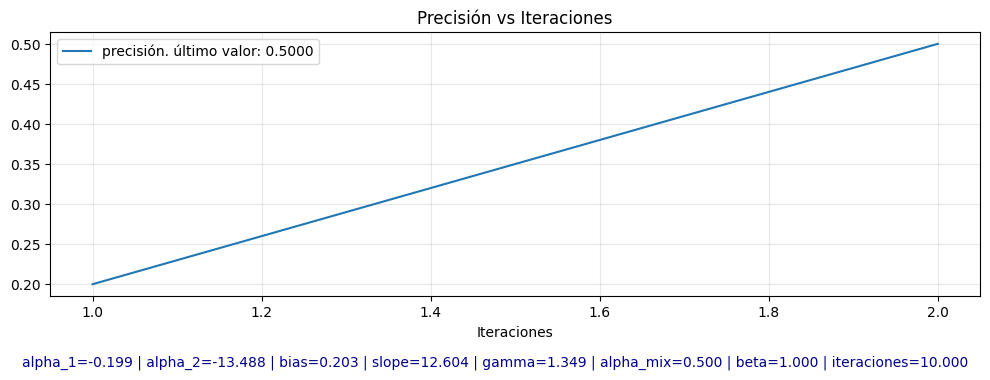

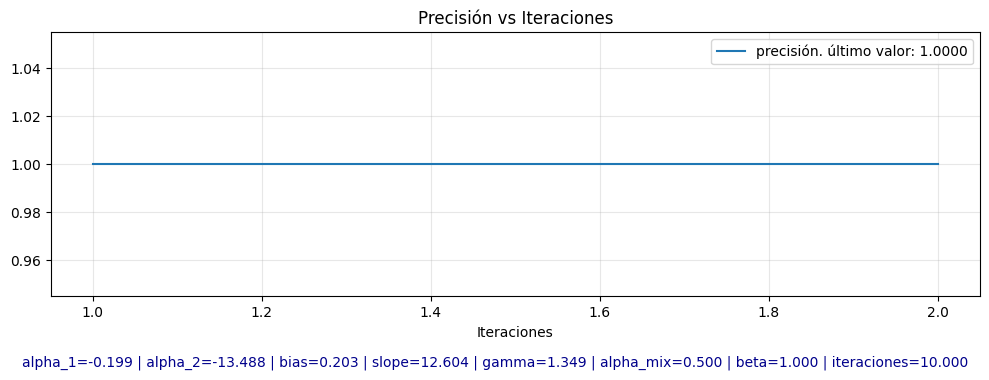

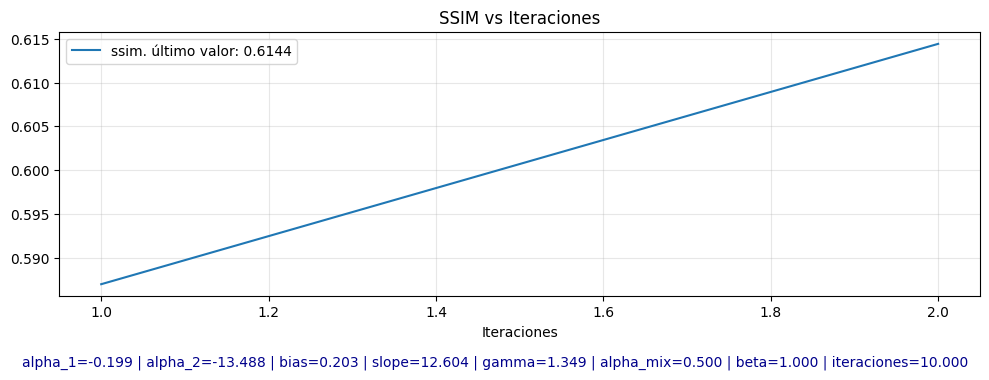

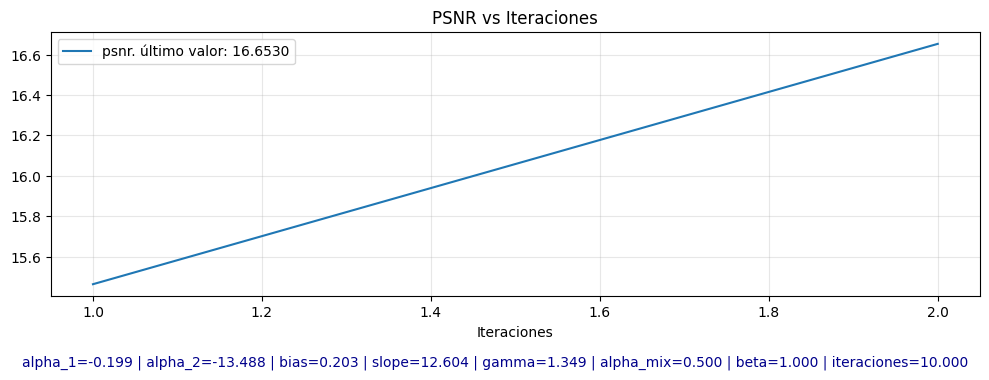


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -0.199
alpha_2     : -13.488
bias        : 0.203
slope       : 12.604
gamma       : 1.349
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 16.653  std:2.234
mask_bpsnr       : mean: 11.173  std:1.760
ssim             : mean: 0.614  std:0.128
acc_at_least_one : 1.000
acc_both         : 0.500



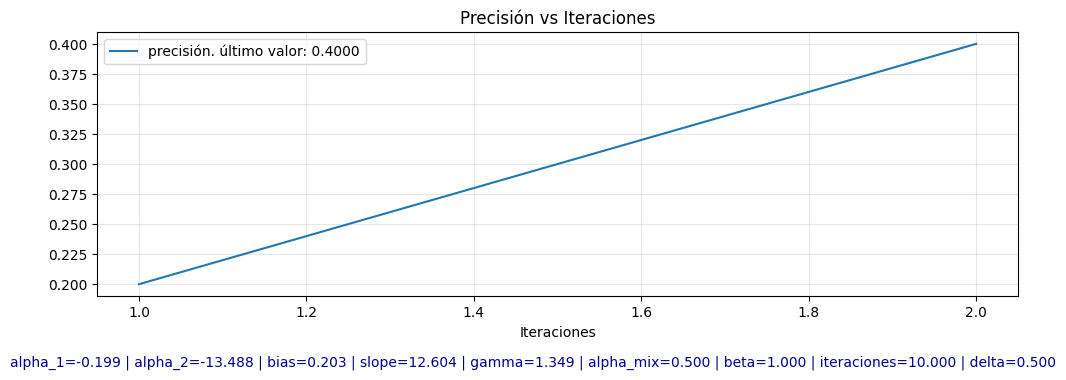

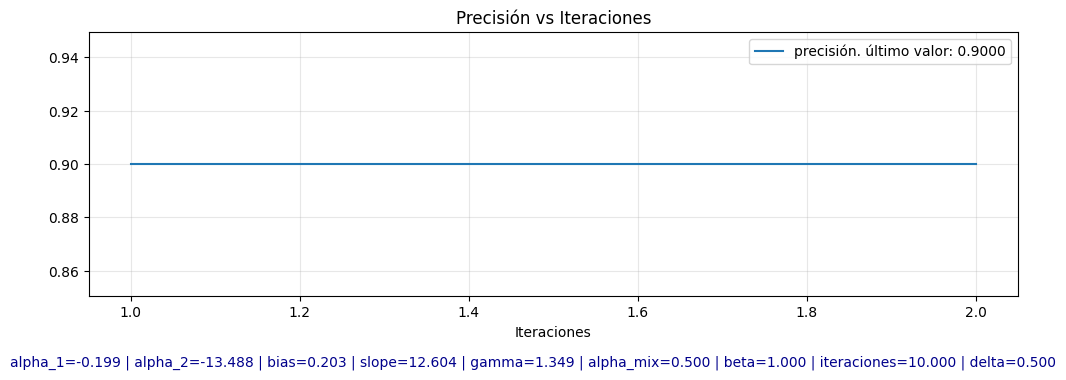

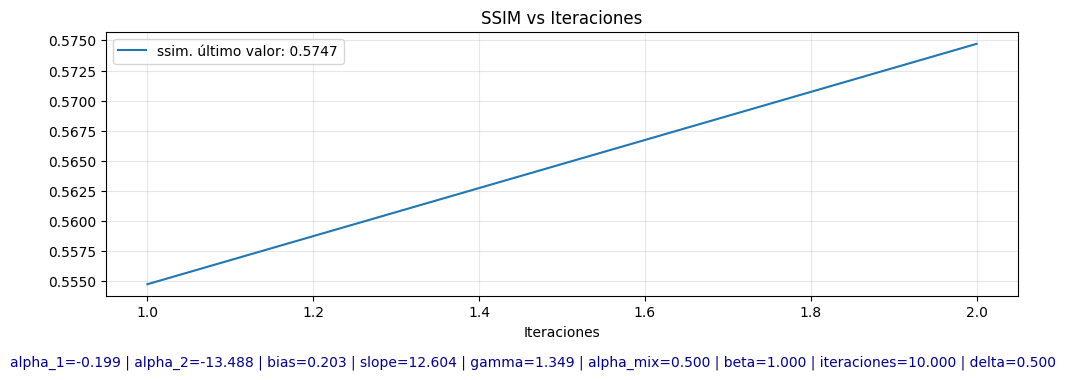

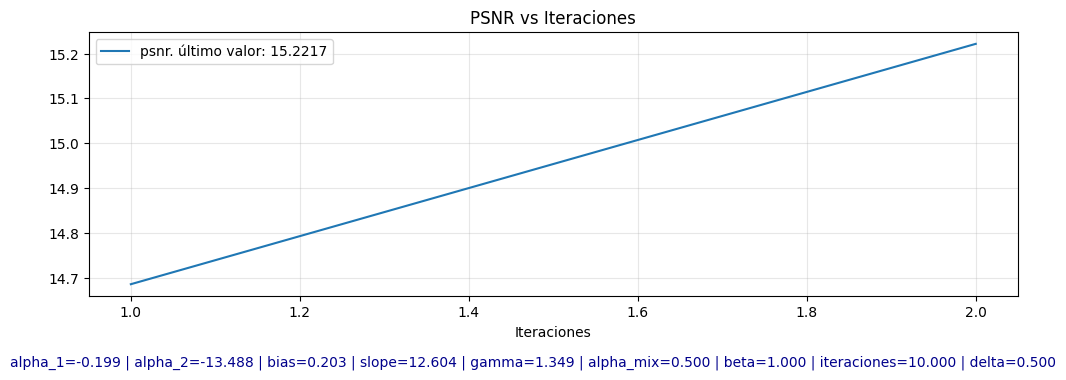


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -0.199
alpha_2     : -13.488
bias        : 0.203
slope       : 12.604
gamma       : 1.349
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.500

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 15.222  std:2.451
mask_bpsnr       : mean: 9.170  std:2.005
ssim             : mean: 0.575  std:0.134
acc_at_least_one : 0.900
acc_both         : 0.400



In [4]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
from project.CROP.models.crop2 import Crop2
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
from project.CROP.models.crop3_all_corrections import Crop3AllCorrections
from project.CROP.models.crop3_one_hot import Crop3OH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random


SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS =2
N_PICTURES = 10

DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 256

MNIST_PARAMS={'alpha_1': -1.061219644037281, 
        'alpha_2': -5.93265175032368, 
        'bias': 0.2181251530229756, 
        'slope': 12.884957541103851, 
        'gamma': 0.3294146902334417}

FASHION_PARAMS={'alpha_1': -0.19868397094671308, 
        'alpha_2': -13.487772584723764, 
        'bias': 0.2025587756051315, 
        'slope': 12.603926712541048, 
        'gamma': 1.348637346498534}
#optimizando ssim

FASHION_PARAMS_SSIM={'alpha_1': -3.67958442342705, 
        'alpha_2': -15.077895121548808, 
        'bias': 0.20255676463340044, 
        'slope': 14.379147657210677, 
        'gamma': 1.569064516257034}


MNIST_PARAMS_SSIM={'alpha_1': -1.9353908509805846, 
                   'alpha_2': -5.702371423422697,
                     'bias': 0.25485332997650295,
                       'slope': 18.19613632092573,
                         'gamma': 1.2494901799145723}



cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]



c2 = Crop2(cvae=cvae,predictor=predictor)


metrics2 = c2.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params=FASHION_PARAMS,
    show_all_curves=True
    )



params = {**FASHION_PARAMS, 'delta': 0.5}
c3 = Crop3EstimationCorrection(cvae=cvae,predictor=predictor)


metrics3ec = c3.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params=params,
    show_all_curves=True
    )




#mejores parametros para Crop3MaskCorrection  optimizando acc_both.

#params={'gamma': 1.136128192066129, 'delta': -1.7913722978884388}

#mejores parametros para Crop3MaskCorrection  optimizando SSIM.

#params={'gamma': 0.32977989566222726, 'delta': 0.7689584803518953}

#----------------------------------------------------------------------

#mejores parametros para Crop3EstimationCorrection  optimizando acc_both.
#params={'gamma': 1.265852455556597, 'delta': 0.3429787390624981}

#mejores parametros para Crop3EstimationCorrection  optimizando SSIM.
#params={'gamma': 1.5420520651370637, 'delta': 0.4771720136717561}





Usando fashion como dataset
Run 1/10


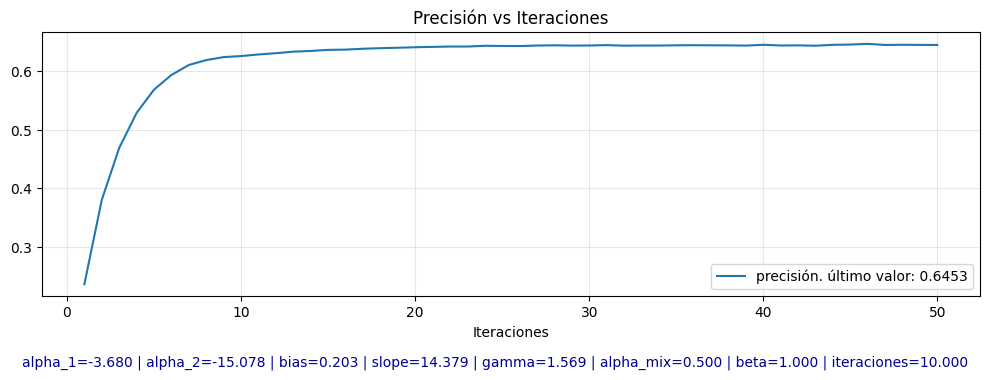

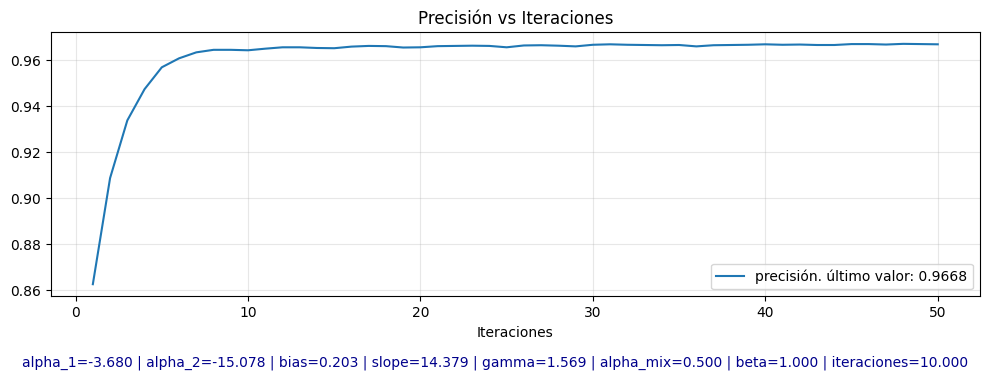

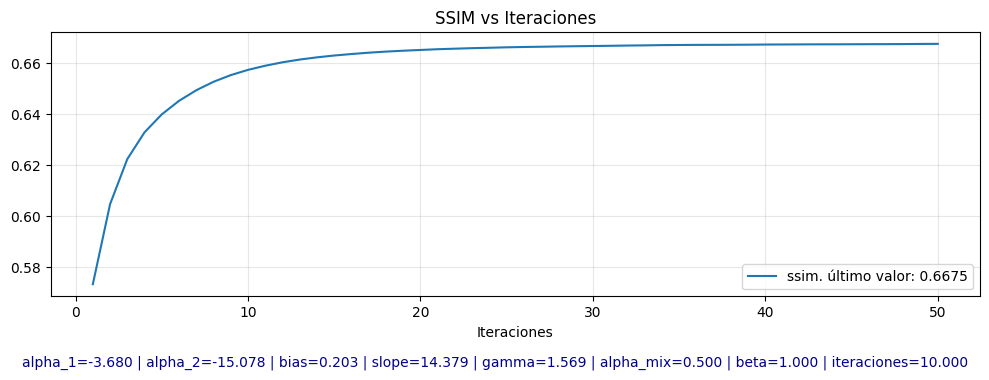

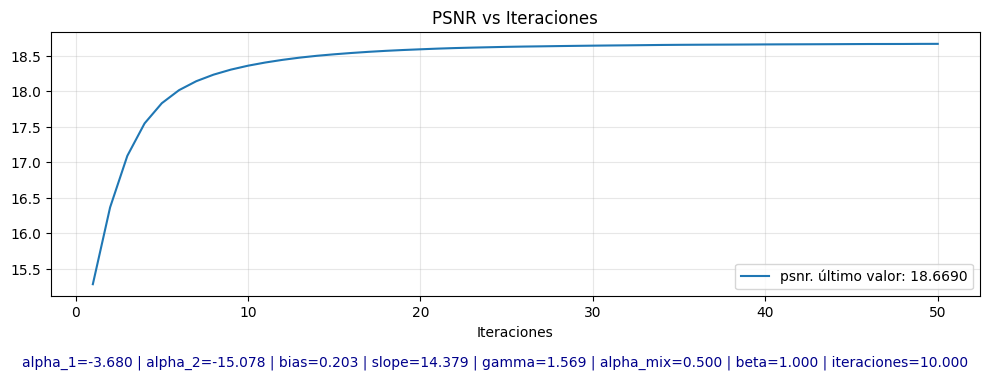


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.669  std:3.227
mask_bpsnr       : mean: 11.887  std:1.573
ssim             : mean: 0.667  std:0.122
acc_at_least_one : 0.967
acc_both         : 0.645



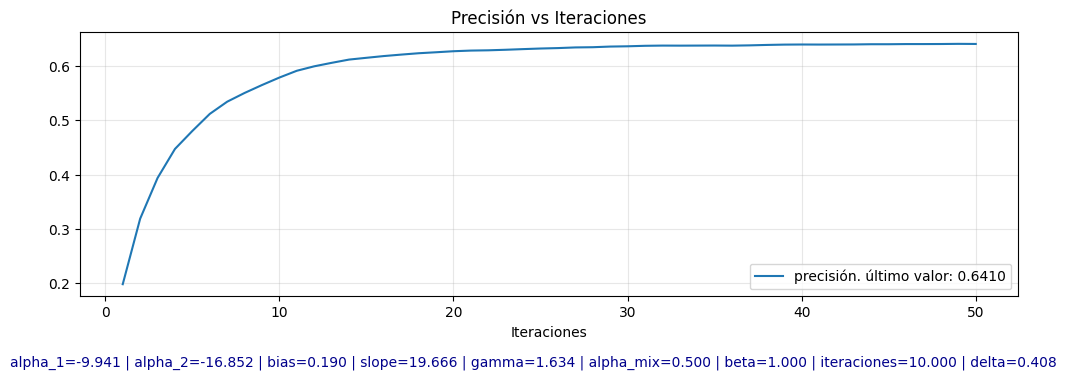

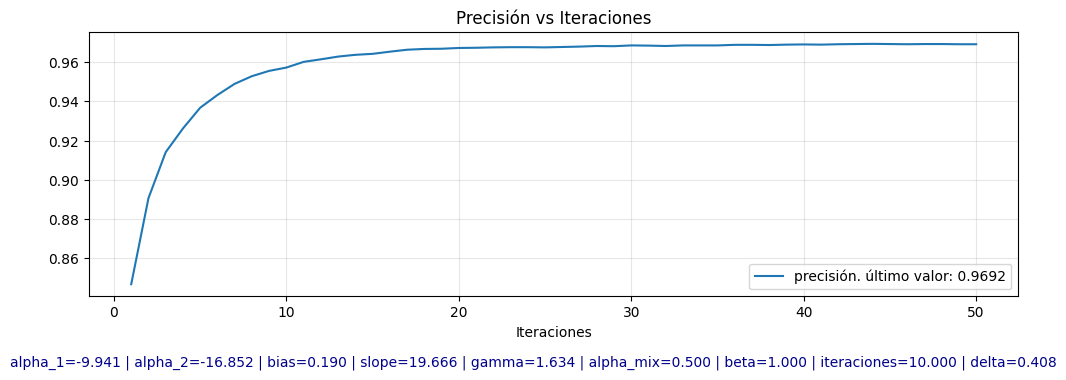

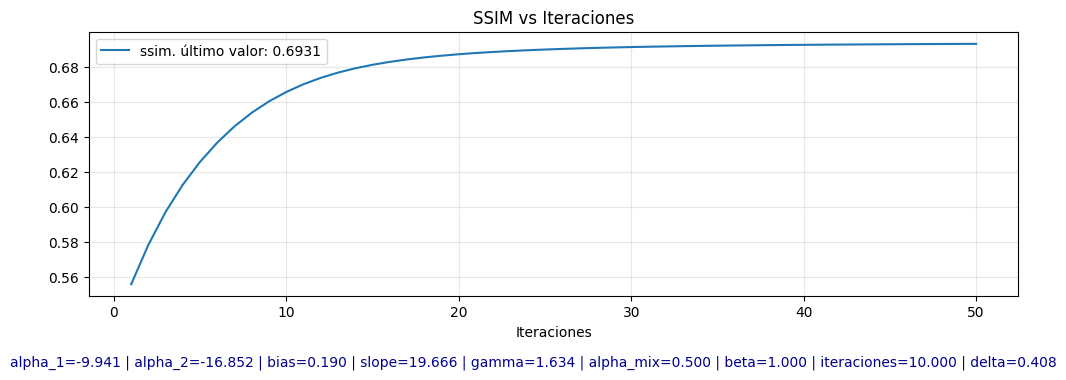

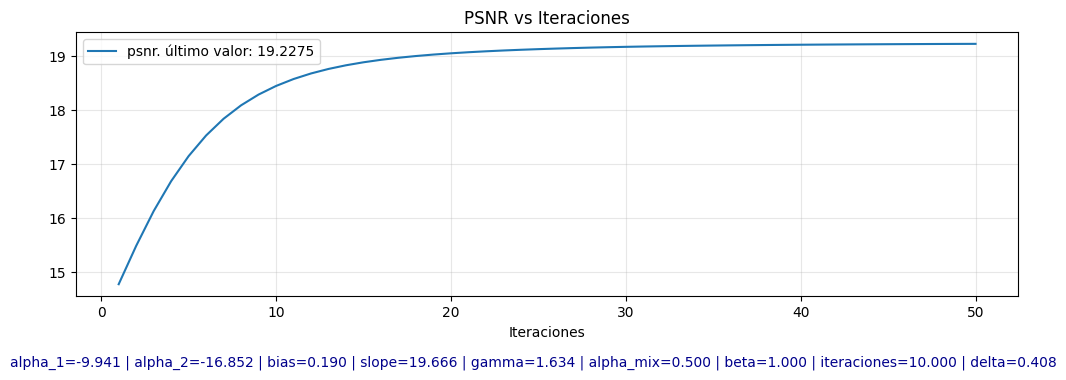


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.228  std:3.060
mask_bpsnr       : mean: 10.899  std:1.573
ssim             : mean: 0.693  std:0.103
acc_at_least_one : 0.969
acc_both         : 0.641

Run 2/10


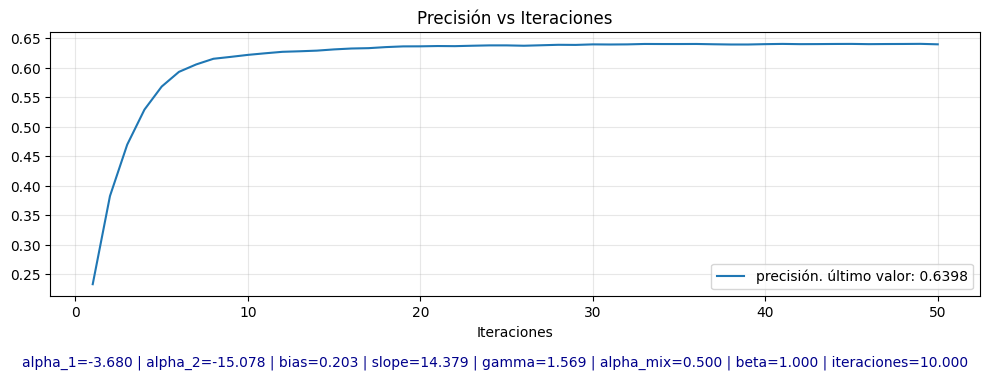

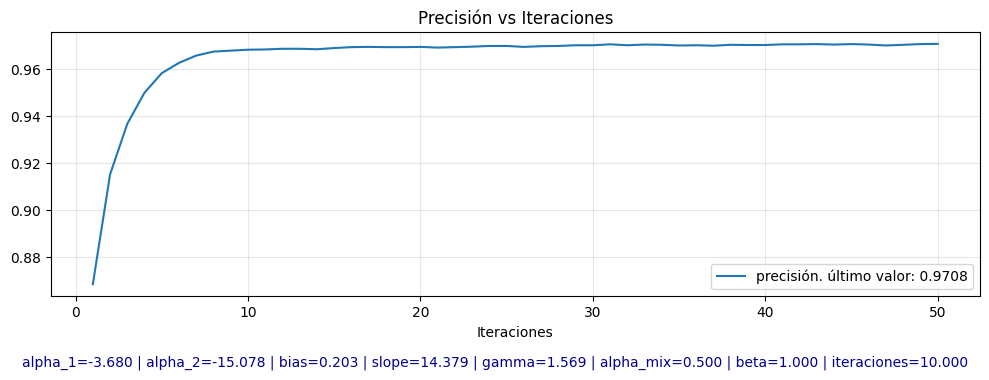

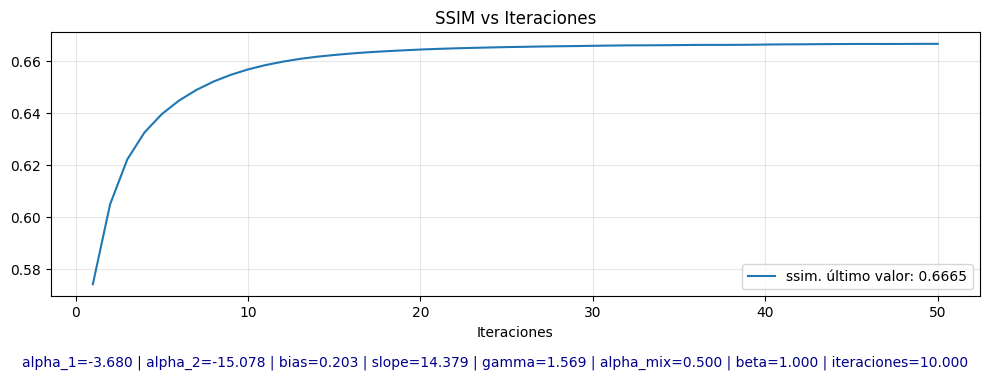

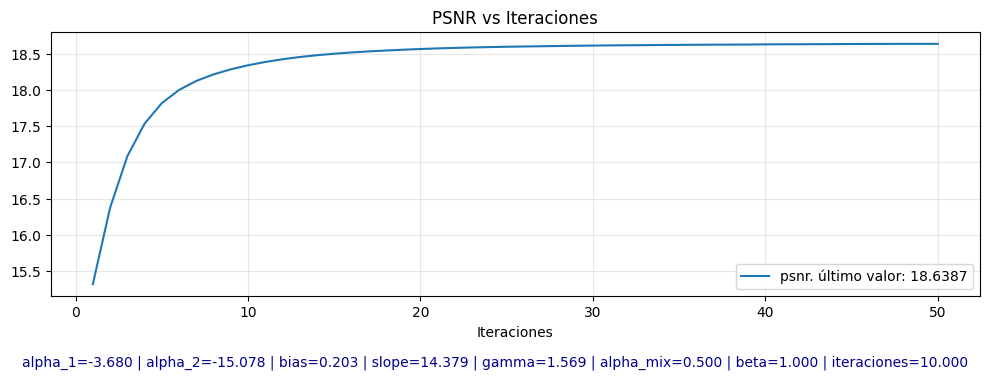


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.639  std:3.230
mask_bpsnr       : mean: 11.876  std:1.590
ssim             : mean: 0.666  std:0.122
acc_at_least_one : 0.971
acc_both         : 0.640



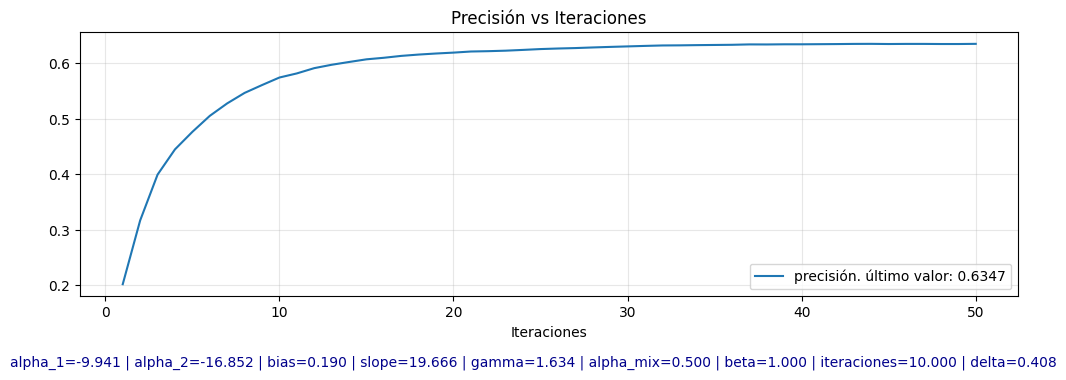

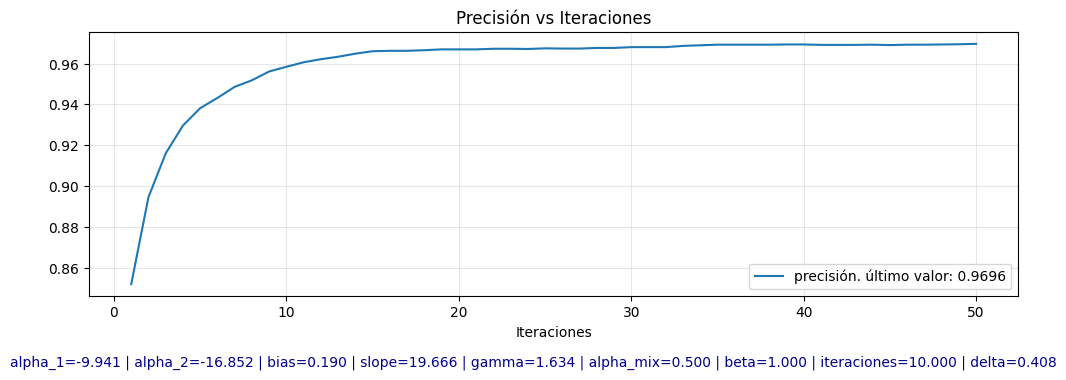

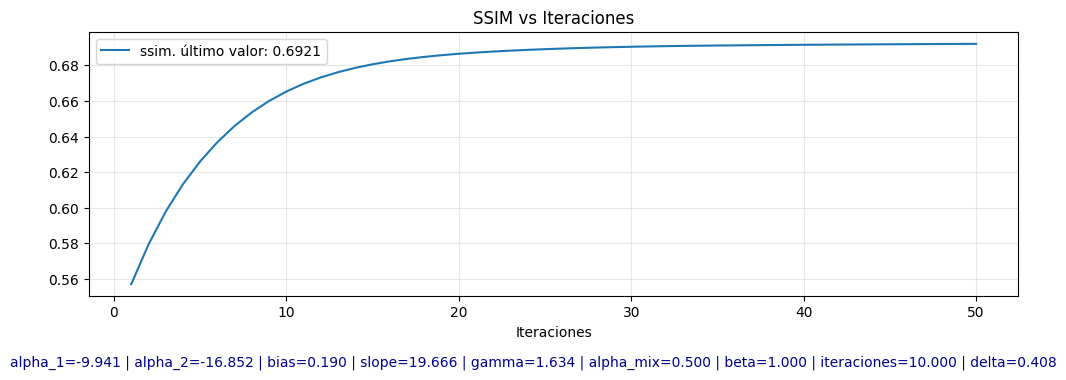

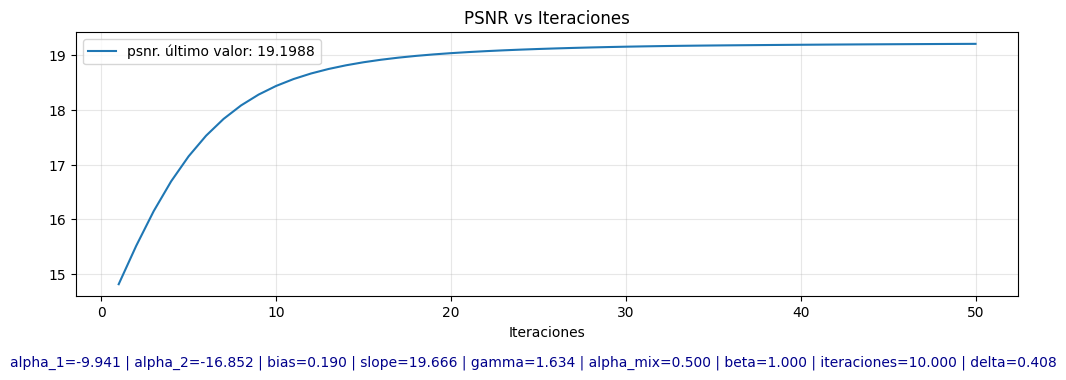


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.199  std:3.068
mask_bpsnr       : mean: 10.891  std:1.599
ssim             : mean: 0.692  std:0.104
acc_at_least_one : 0.970
acc_both         : 0.635

Run 3/10


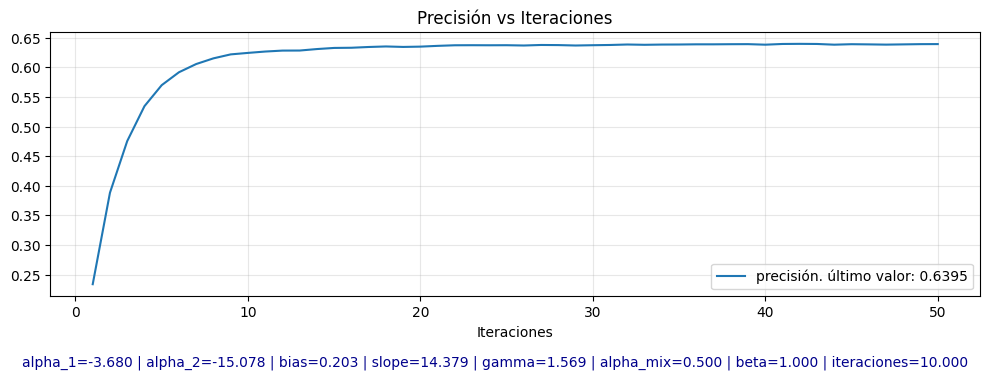

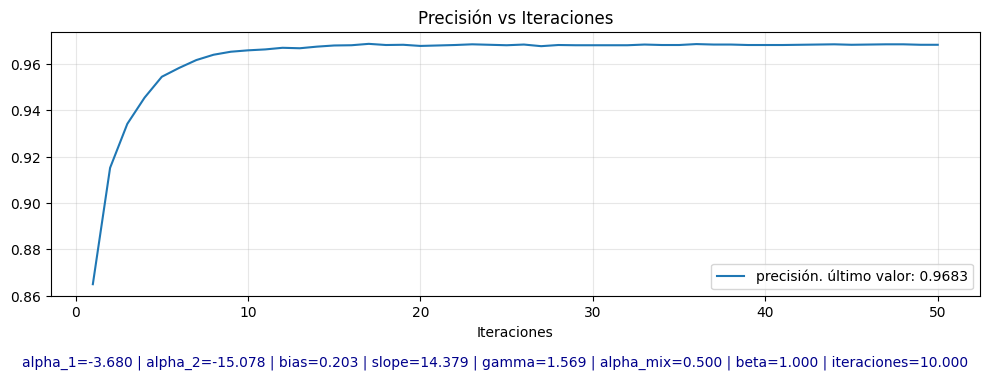

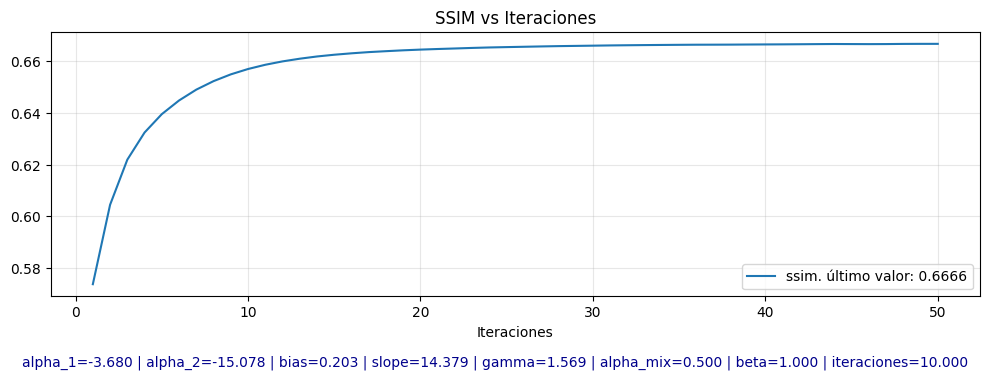

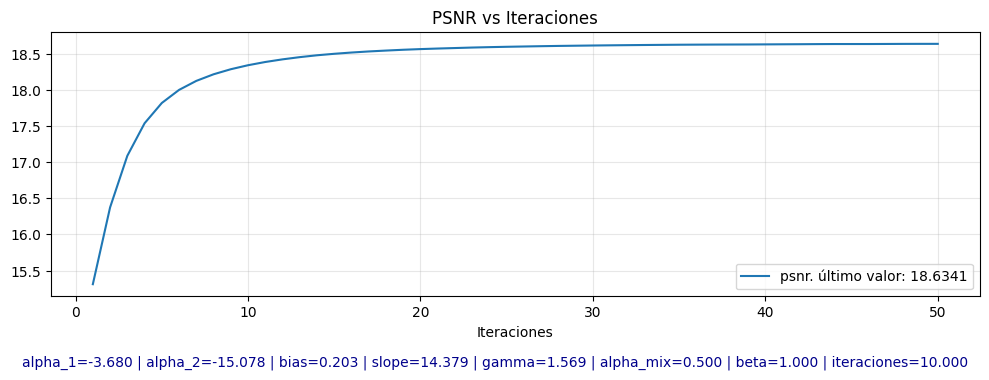


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.634  std:3.235
mask_bpsnr       : mean: 11.867  std:1.594
ssim             : mean: 0.667  std:0.122
acc_at_least_one : 0.968
acc_both         : 0.639



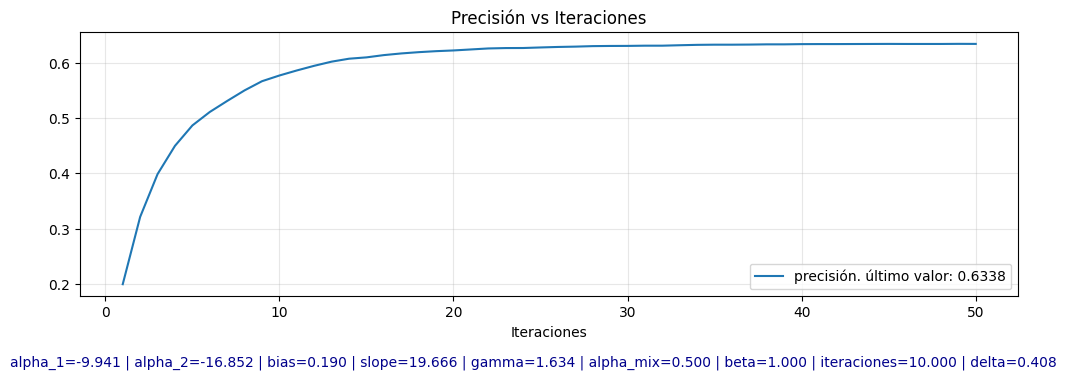

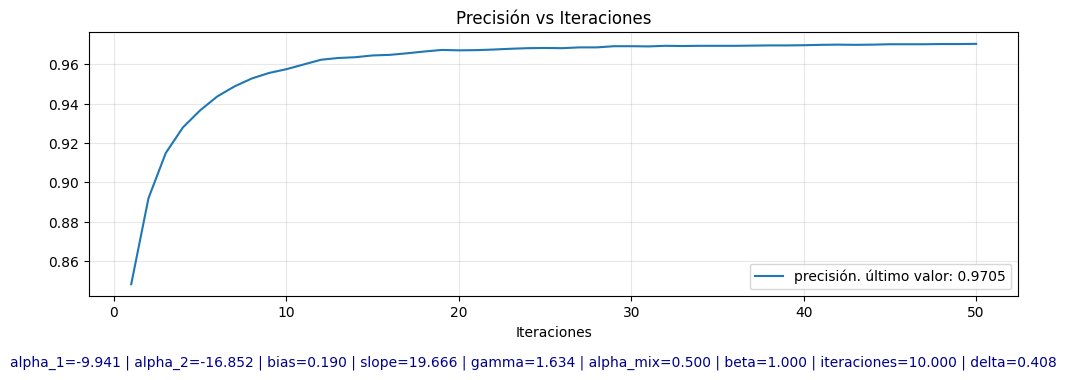

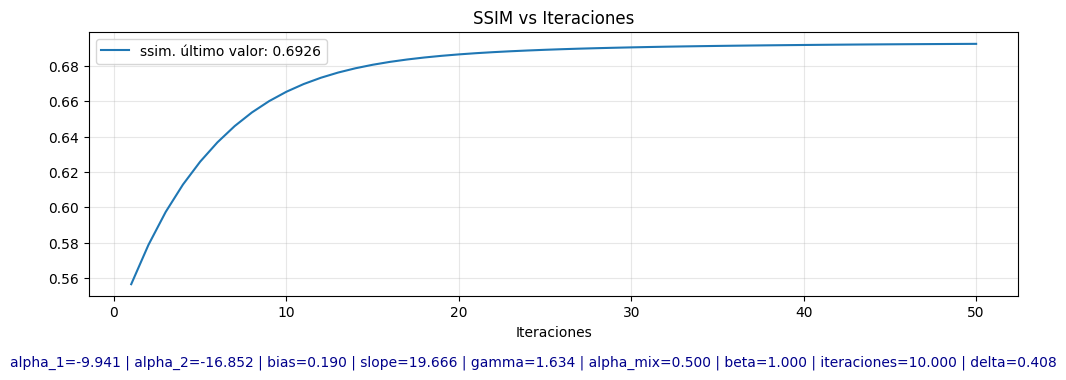

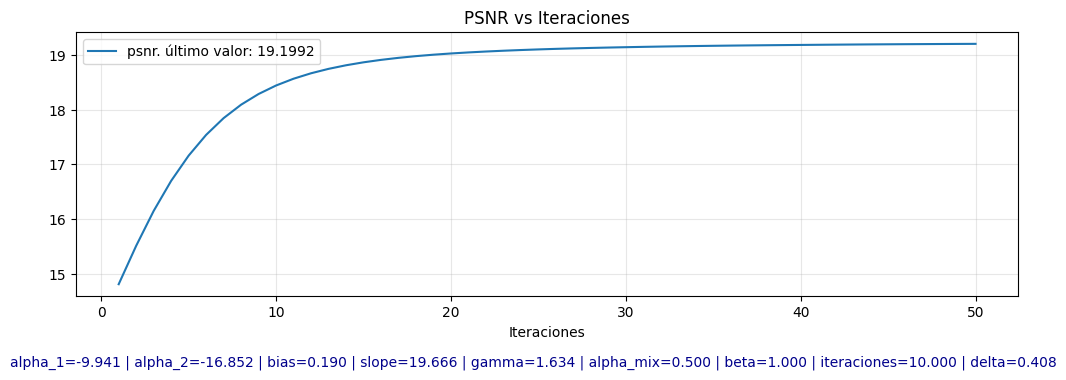


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.199  std:3.071
mask_bpsnr       : mean: 10.890  std:1.588
ssim             : mean: 0.693  std:0.104
acc_at_least_one : 0.971
acc_both         : 0.634

Run 4/10


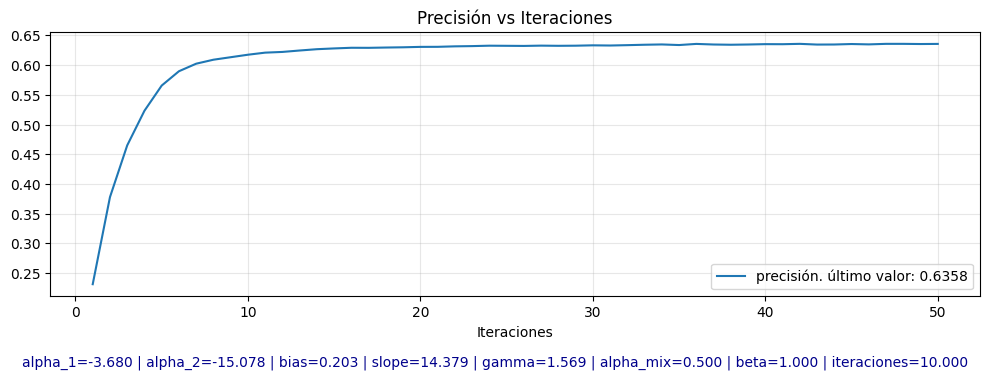

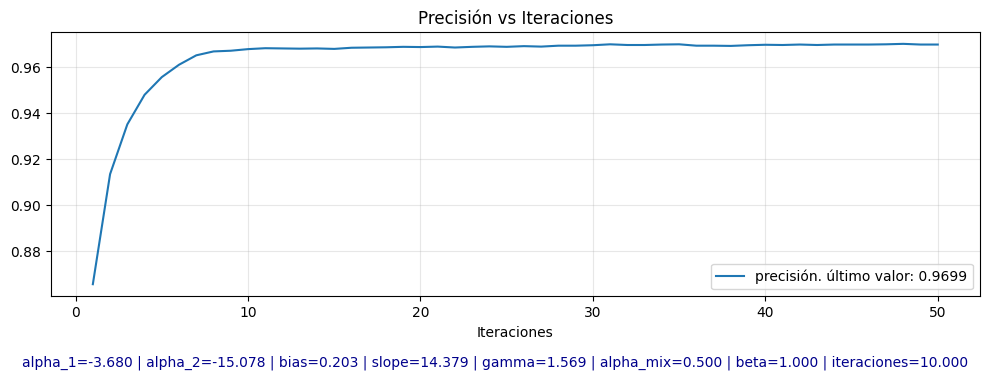

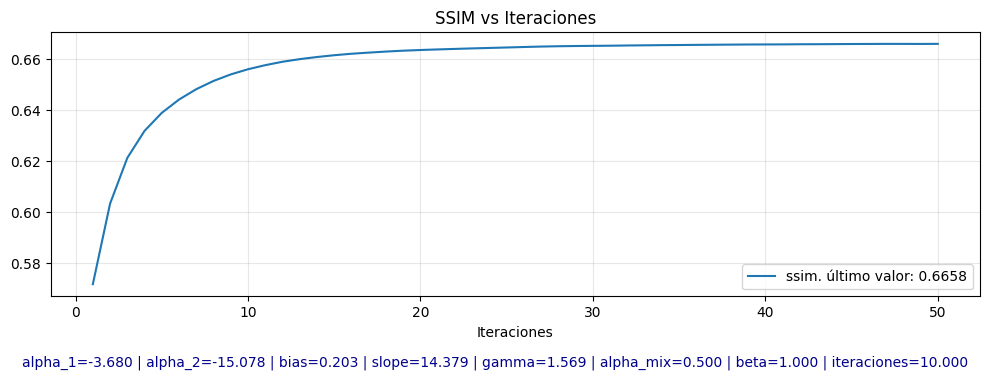

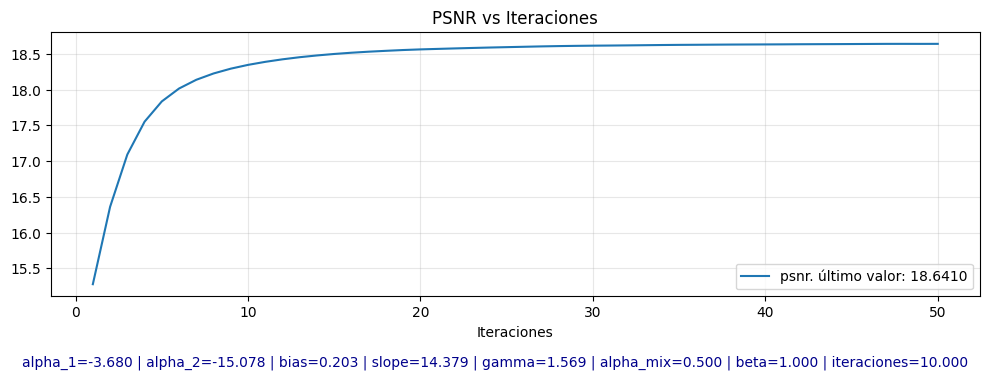


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.641  std:3.235
mask_bpsnr       : mean: 11.871  std:1.587
ssim             : mean: 0.666  std:0.122
acc_at_least_one : 0.970
acc_both         : 0.636



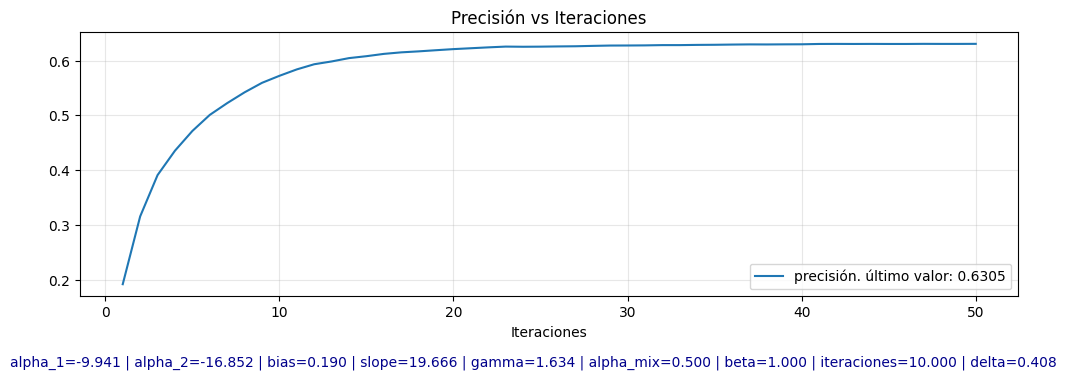

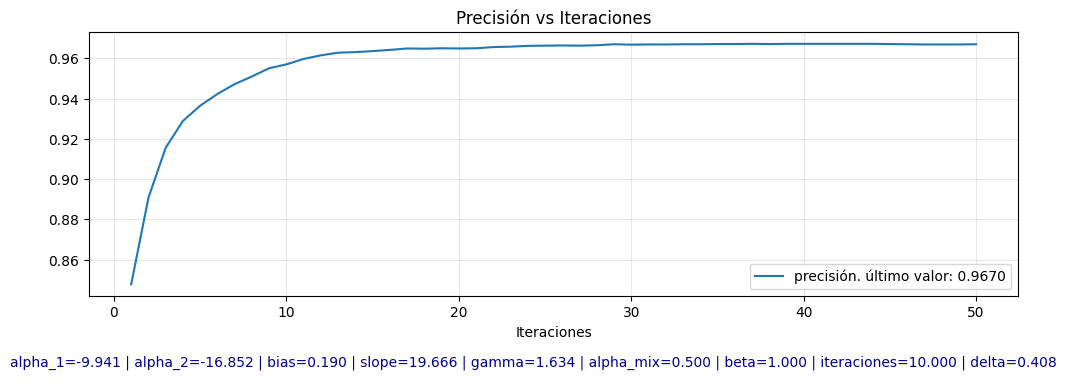

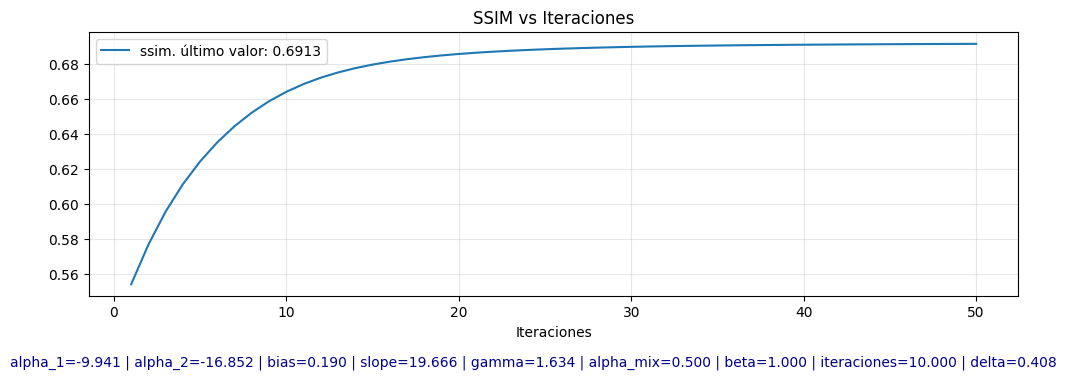

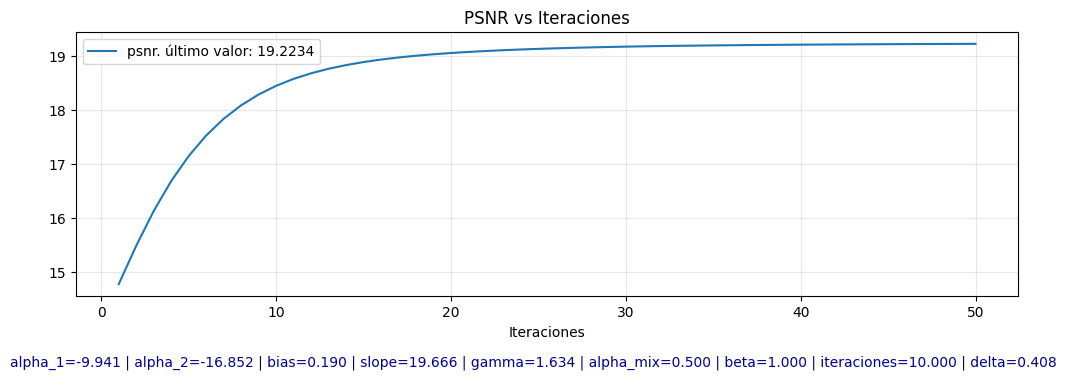


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.223  std:3.080
mask_bpsnr       : mean: 10.887  std:1.597
ssim             : mean: 0.691  std:0.104
acc_at_least_one : 0.967
acc_both         : 0.630

Run 5/10


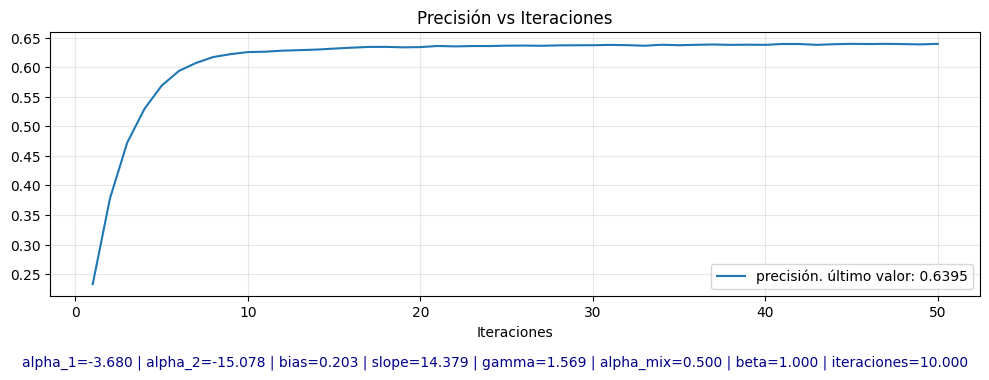

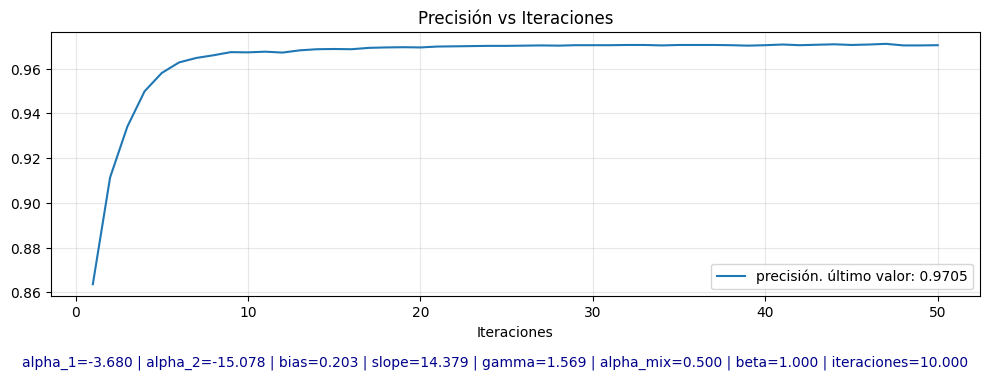

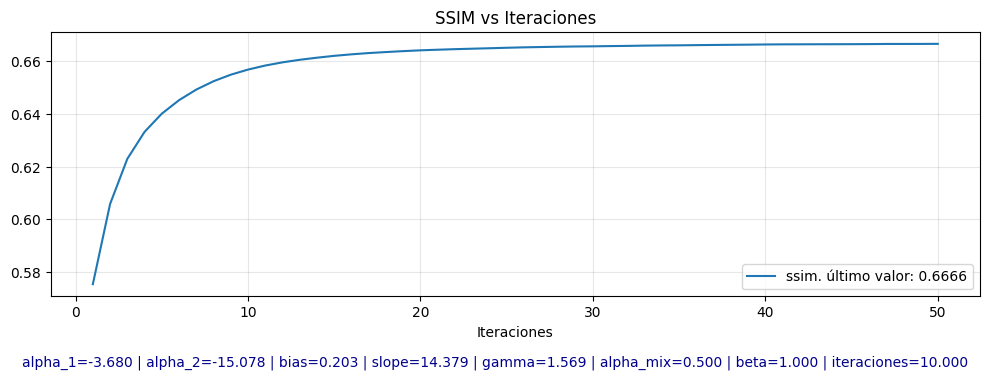

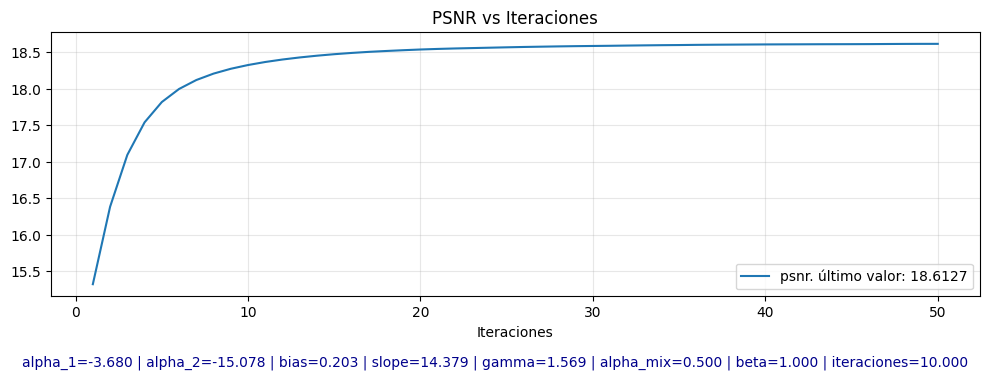


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.613  std:3.204
mask_bpsnr       : mean: 11.876  std:1.592
ssim             : mean: 0.667  std:0.122
acc_at_least_one : 0.971
acc_both         : 0.639



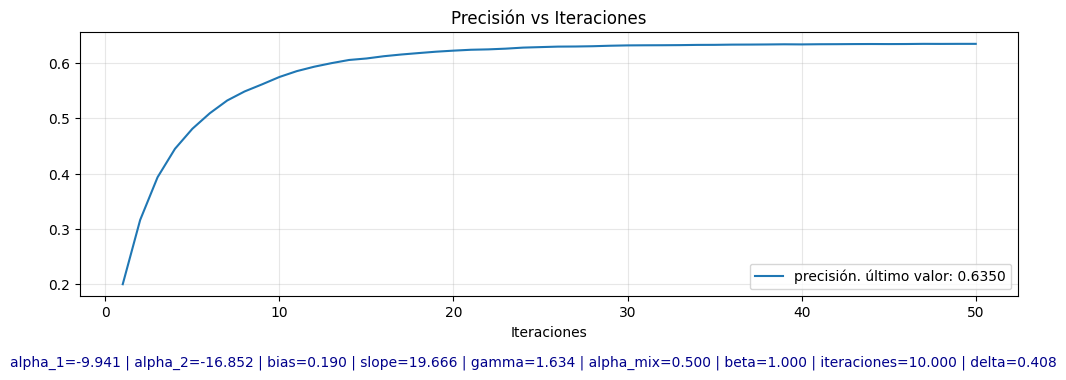

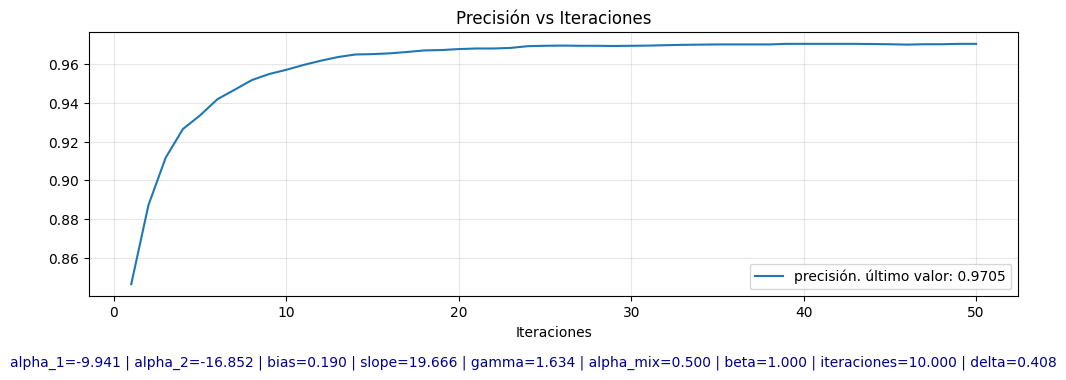

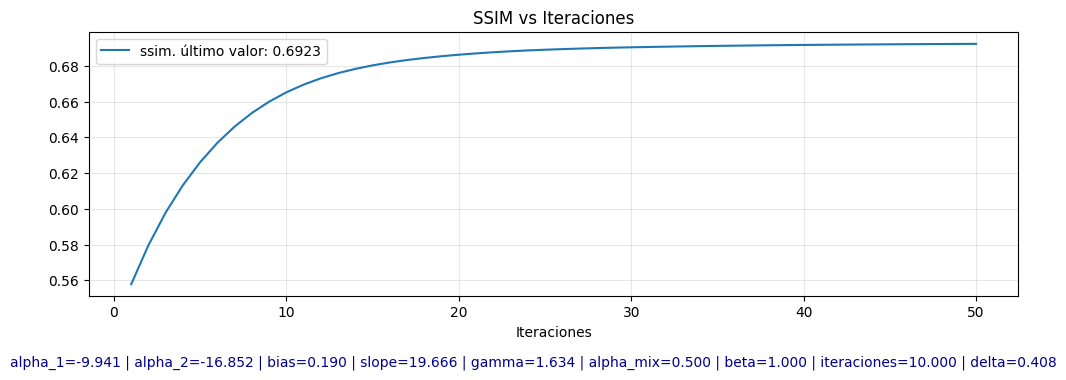

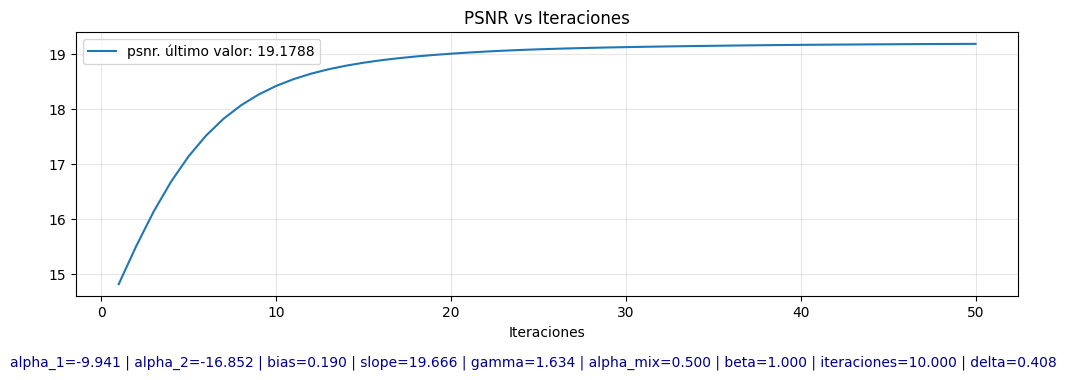


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.179  std:3.043
mask_bpsnr       : mean: 10.894  std:1.604
ssim             : mean: 0.692  std:0.104
acc_at_least_one : 0.971
acc_both         : 0.635

Run 6/10


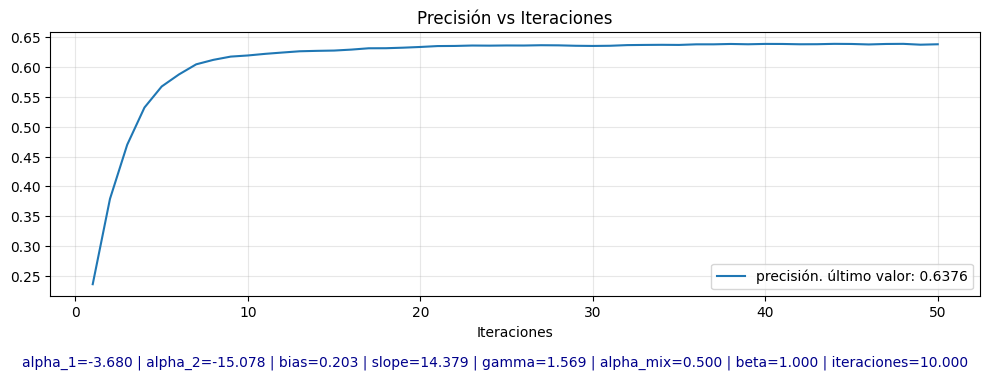

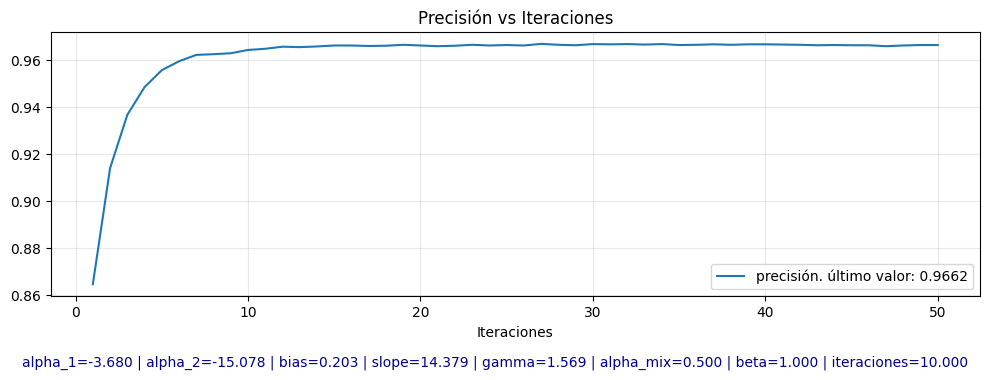

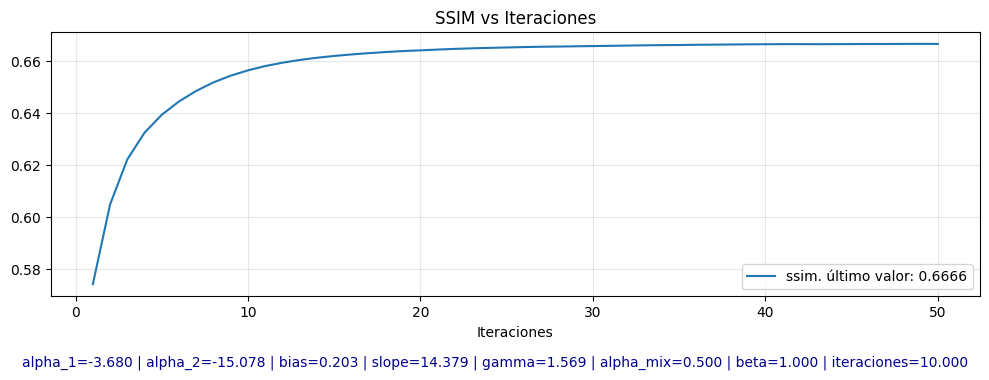

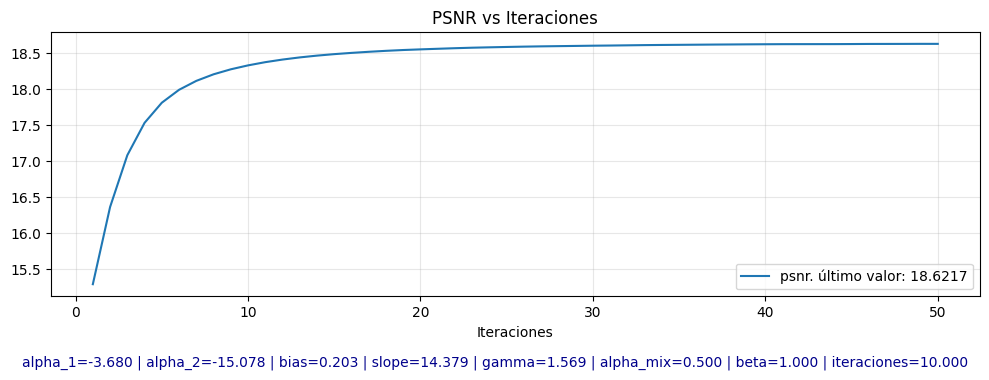


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.622  std:3.228
mask_bpsnr       : mean: 11.871  std:1.586
ssim             : mean: 0.667  std:0.121
acc_at_least_one : 0.966
acc_both         : 0.638



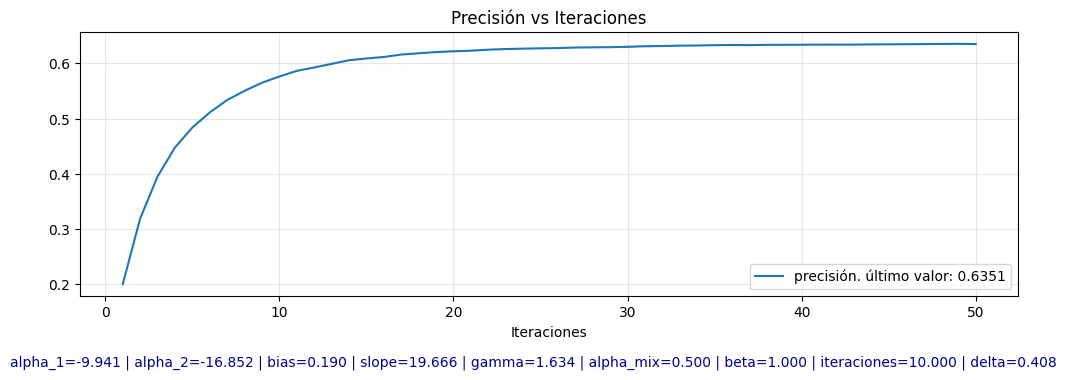

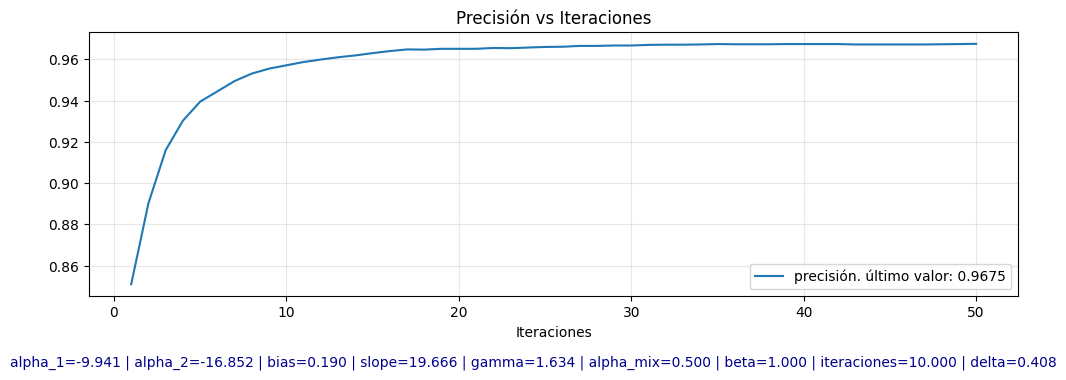

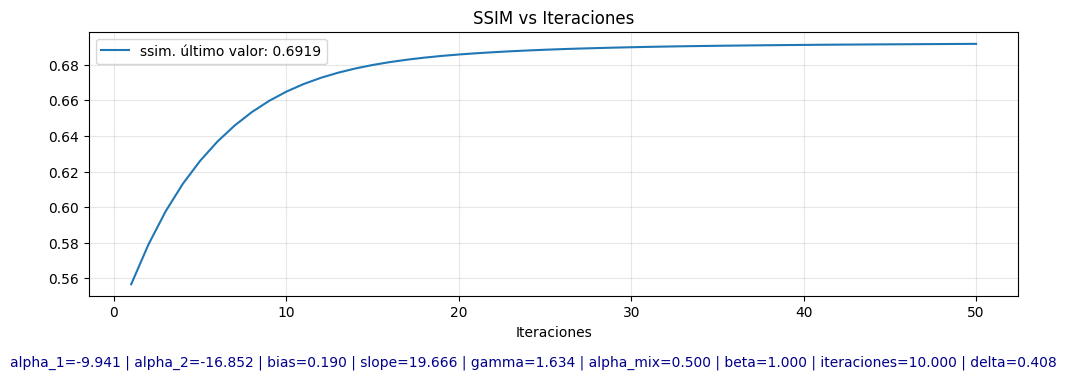

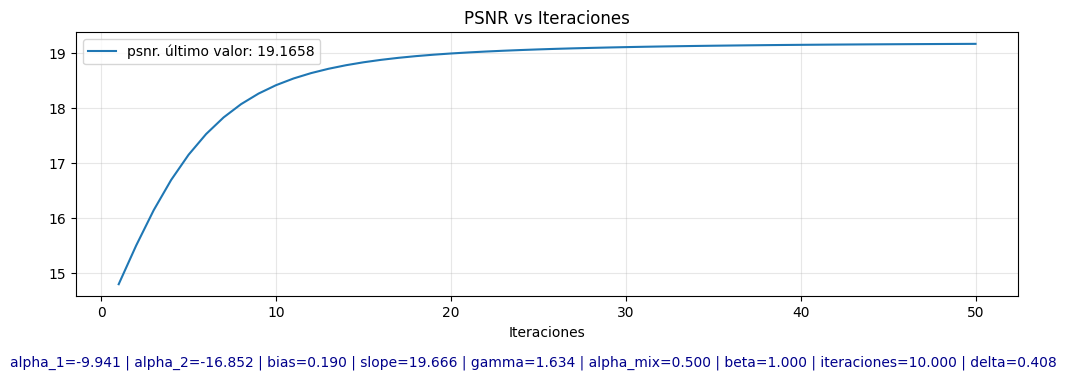


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.166  std:3.089
mask_bpsnr       : mean: 10.886  std:1.597
ssim             : mean: 0.692  std:0.104
acc_at_least_one : 0.968
acc_both         : 0.635

Run 7/10


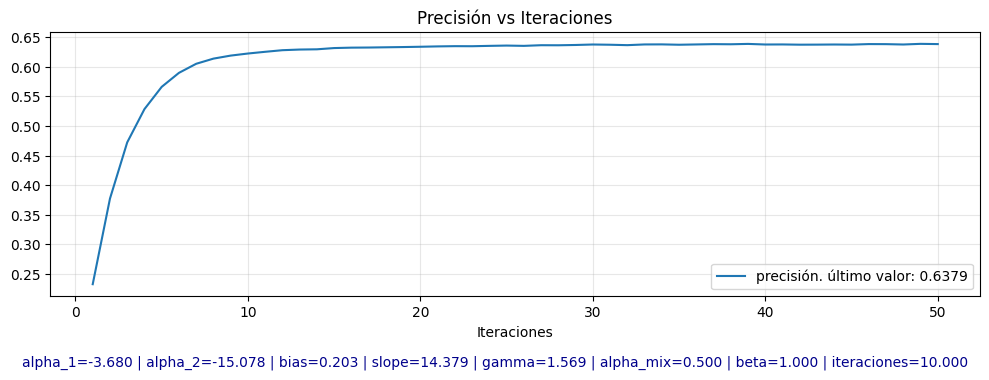

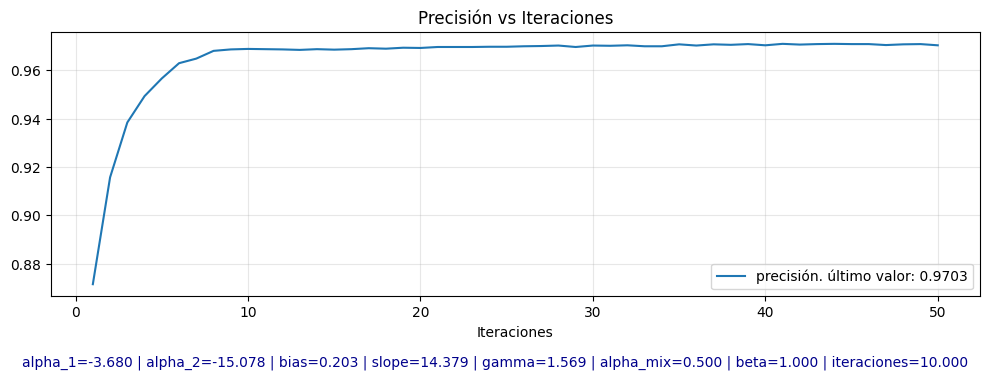

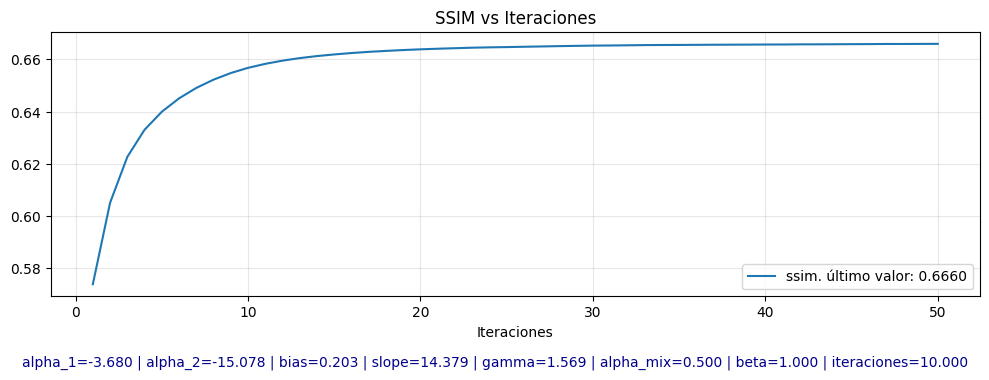

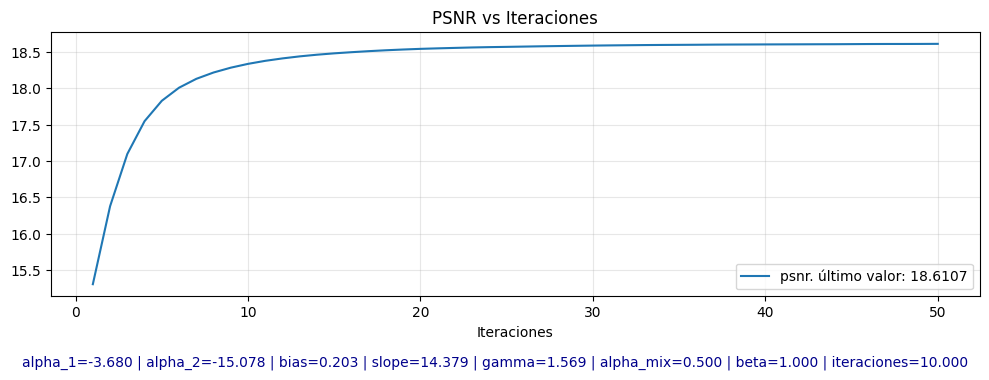


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.611  std:3.258
mask_bpsnr       : mean: 11.873  std:1.586
ssim             : mean: 0.666  std:0.122
acc_at_least_one : 0.970
acc_both         : 0.638



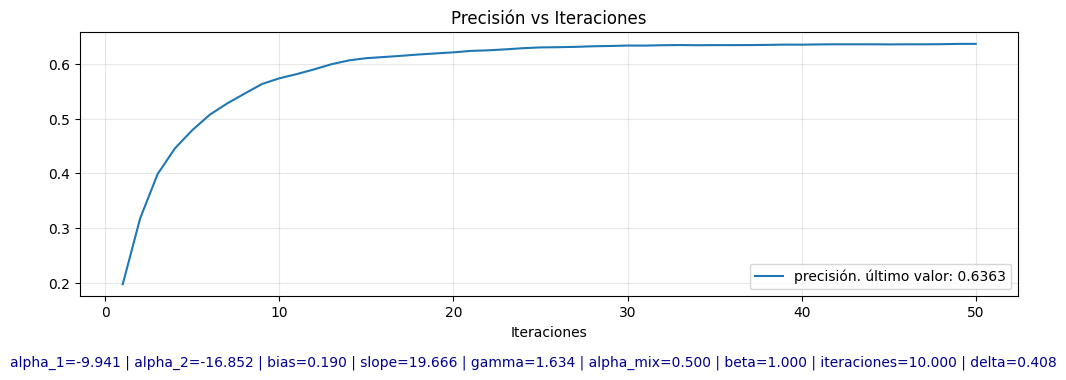

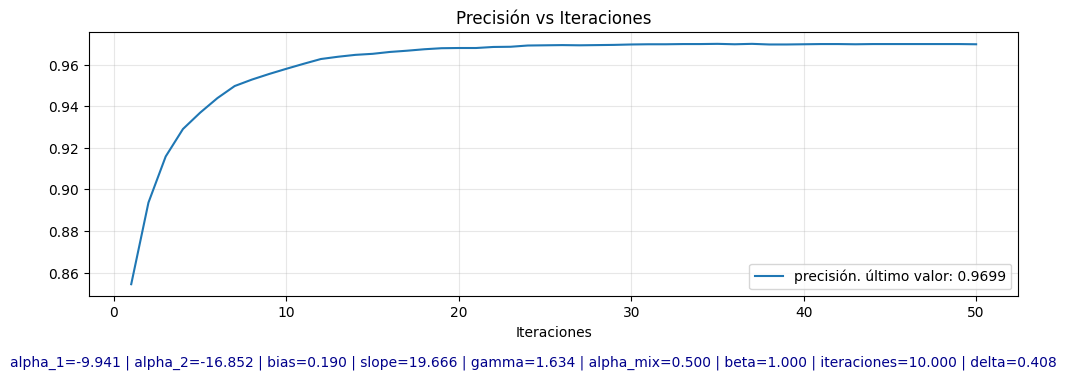

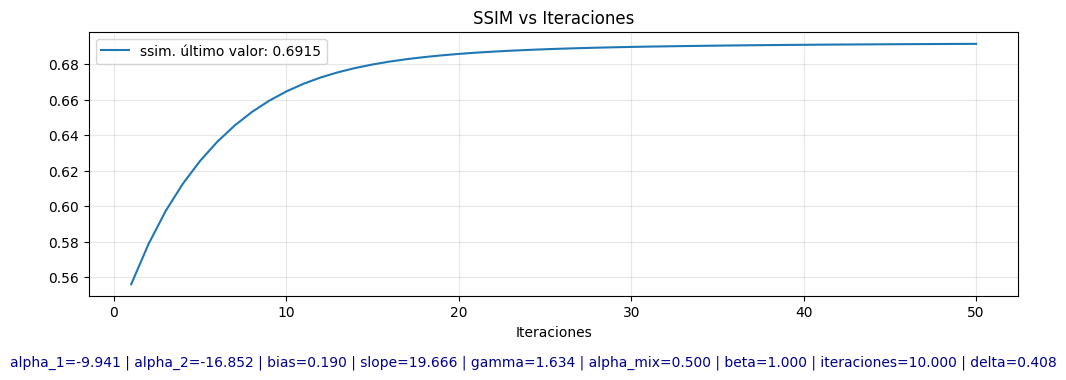

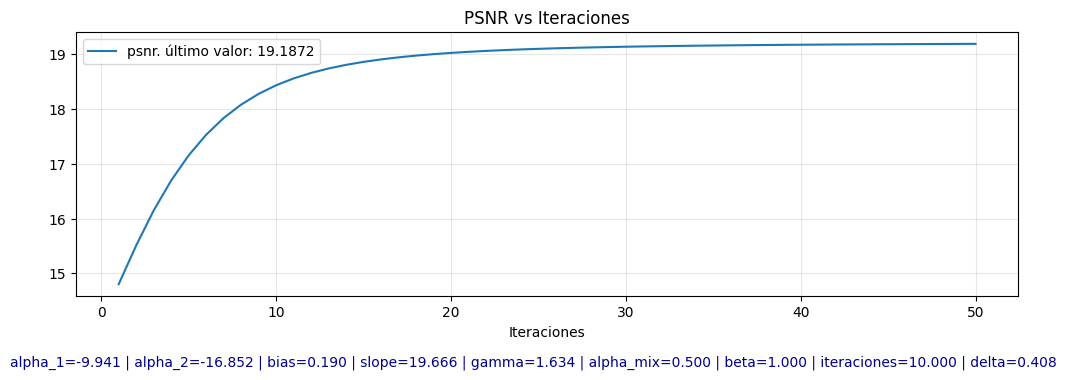


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.187  std:3.103
mask_bpsnr       : mean: 10.889  std:1.589
ssim             : mean: 0.692  std:0.104
acc_at_least_one : 0.970
acc_both         : 0.636

Run 8/10


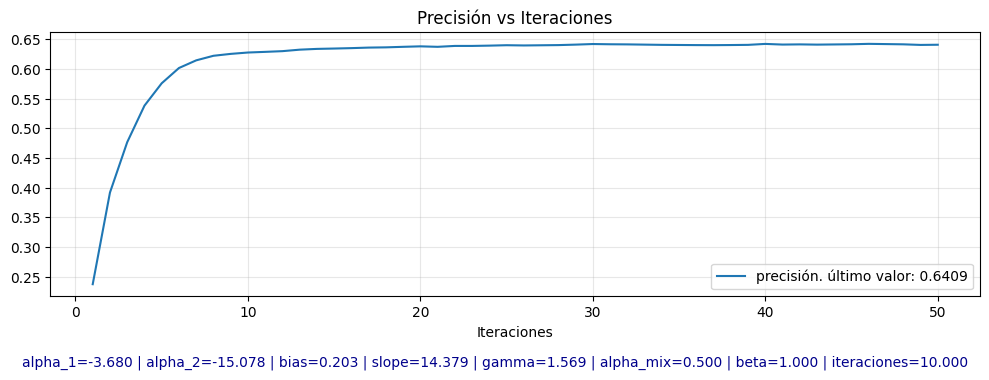

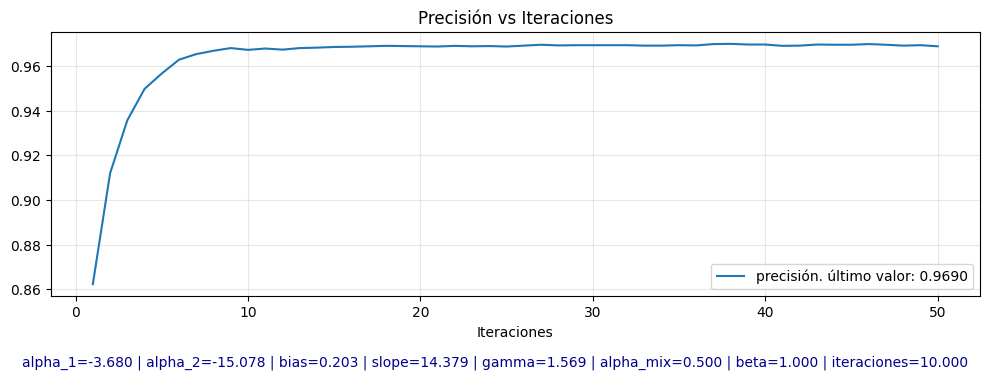

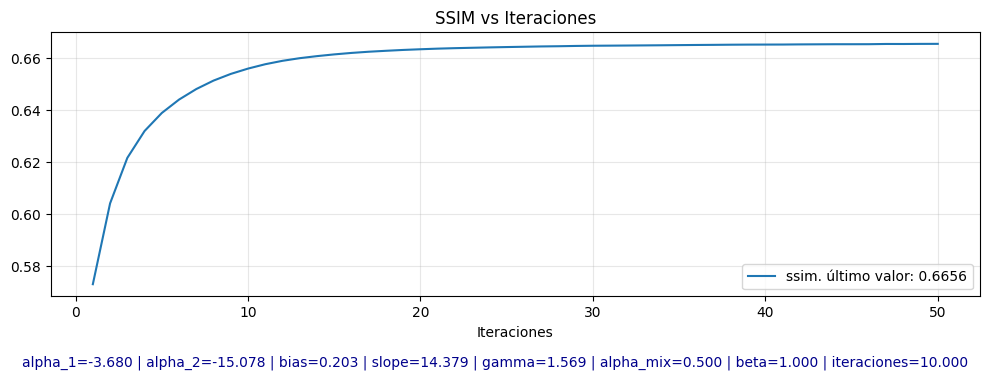

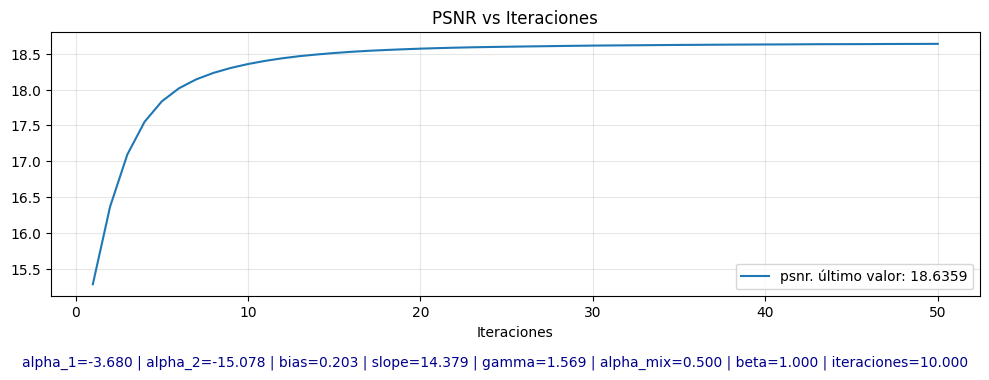


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.636  std:3.261
mask_bpsnr       : mean: 11.874  std:1.593
ssim             : mean: 0.666  std:0.123
acc_at_least_one : 0.969
acc_both         : 0.641



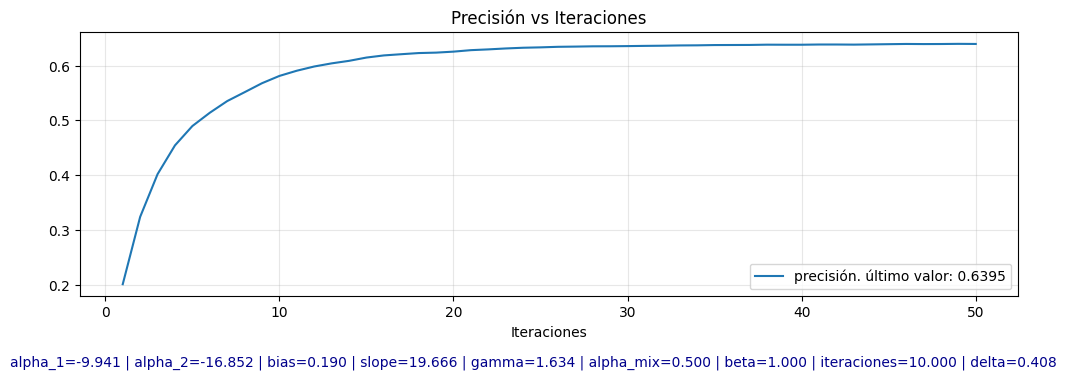

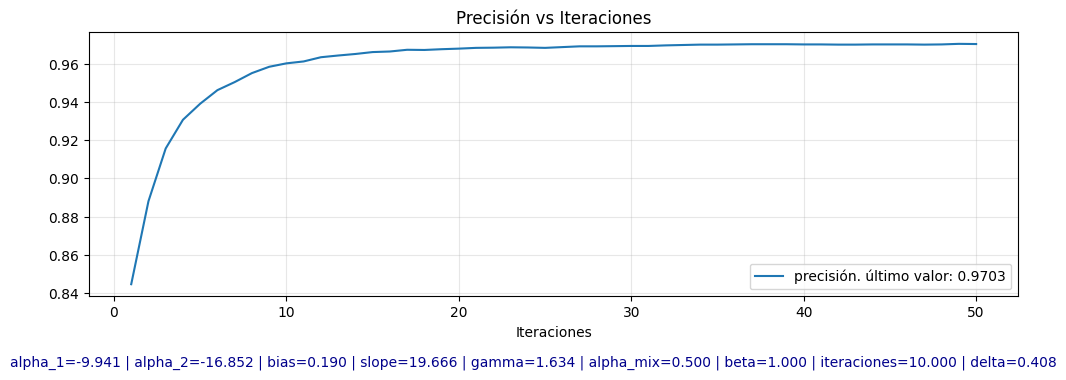

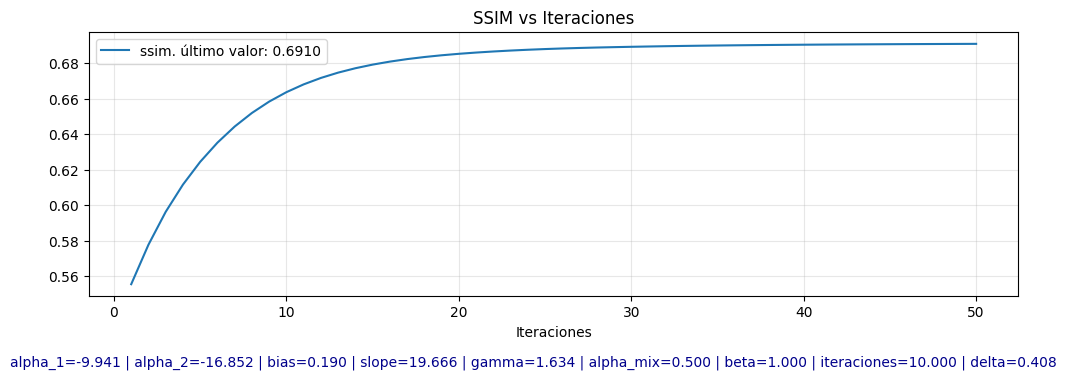

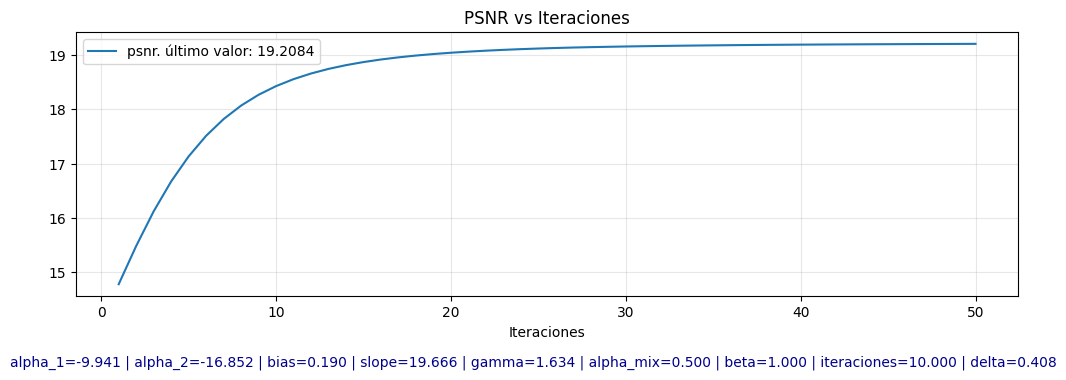


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.208  std:3.110
mask_bpsnr       : mean: 10.900  std:1.590
ssim             : mean: 0.691  std:0.105
acc_at_least_one : 0.970
acc_both         : 0.639

Run 9/10


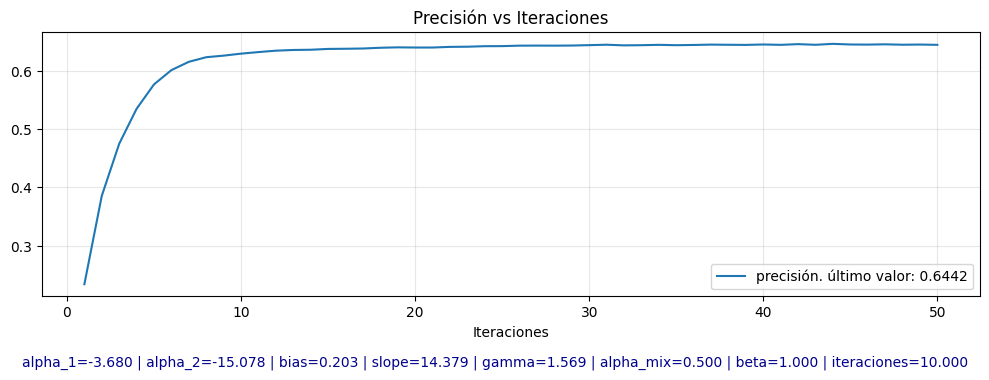

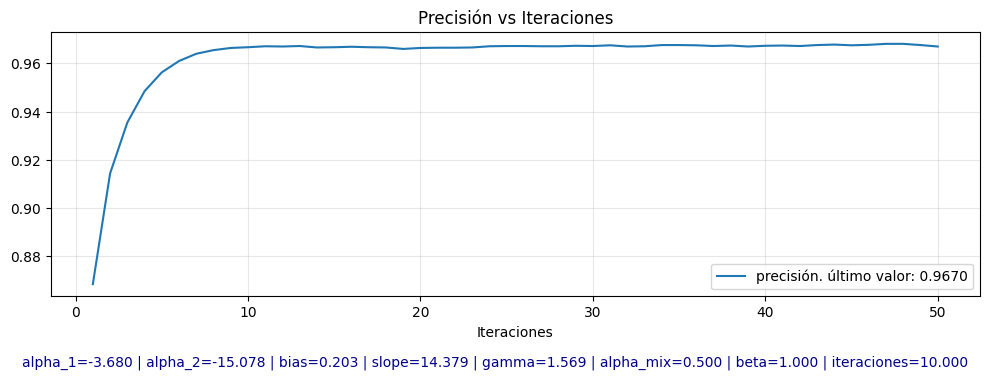

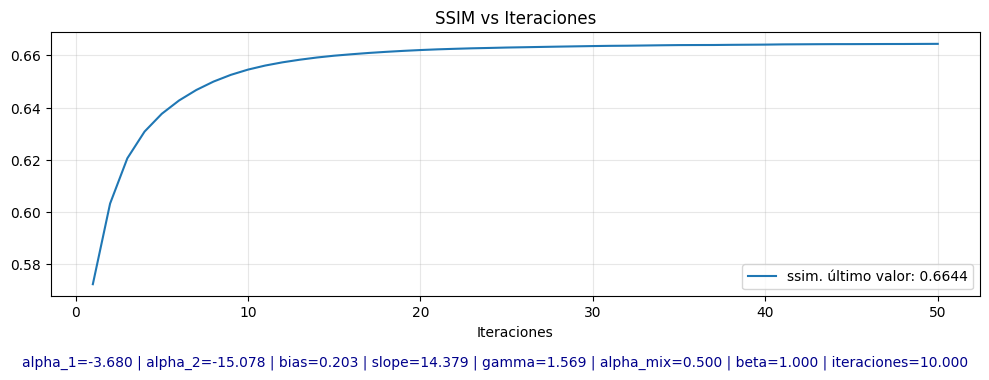

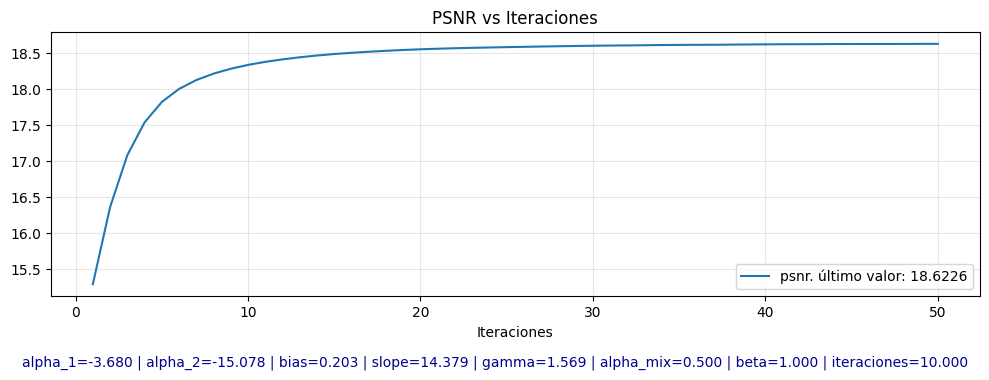


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.623  std:3.266
mask_bpsnr       : mean: 11.856  std:1.593
ssim             : mean: 0.664  std:0.124
acc_at_least_one : 0.967
acc_both         : 0.644



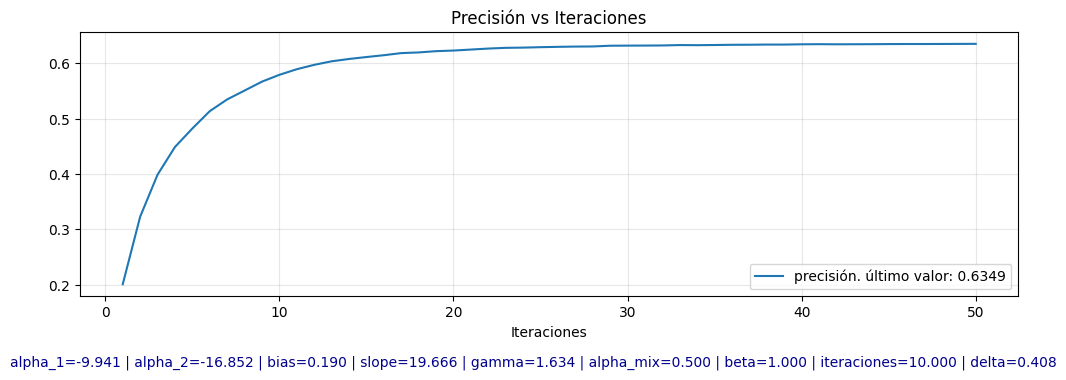

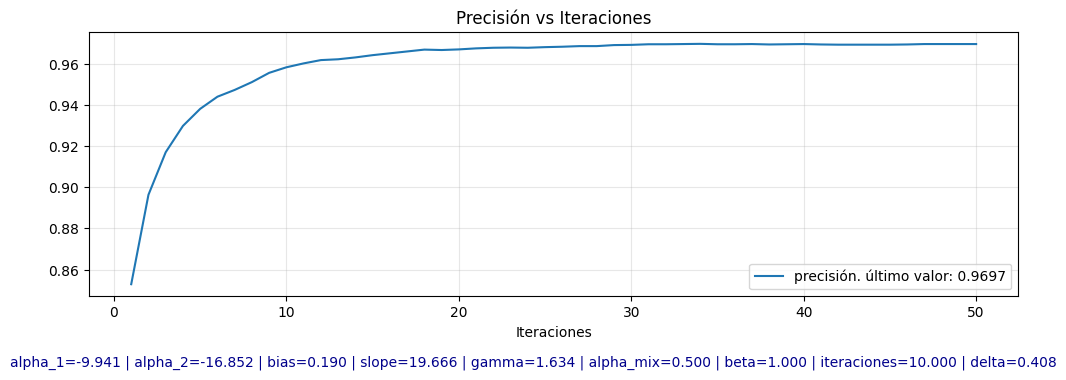

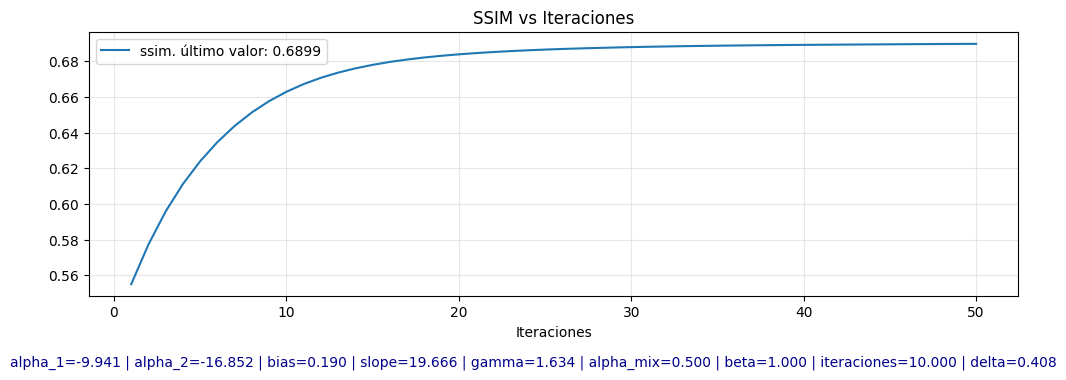

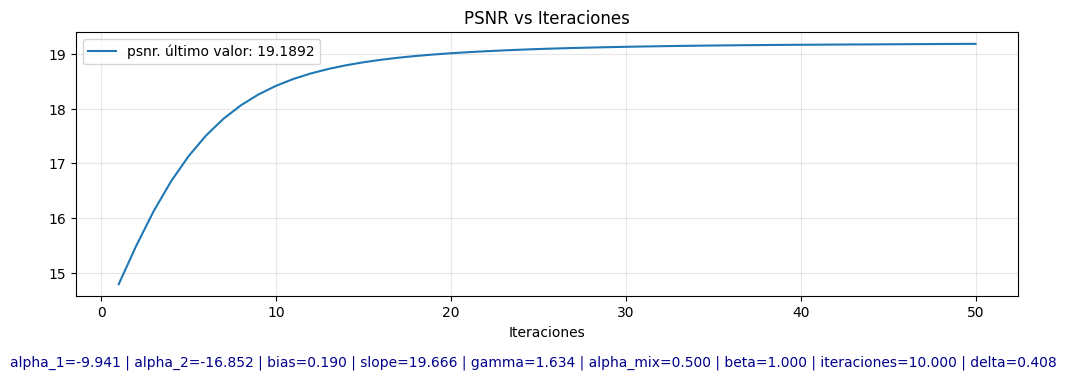


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.189  std:3.124
mask_bpsnr       : mean: 10.882  std:1.592
ssim             : mean: 0.690  std:0.107
acc_at_least_one : 0.970
acc_both         : 0.635

Run 10/10


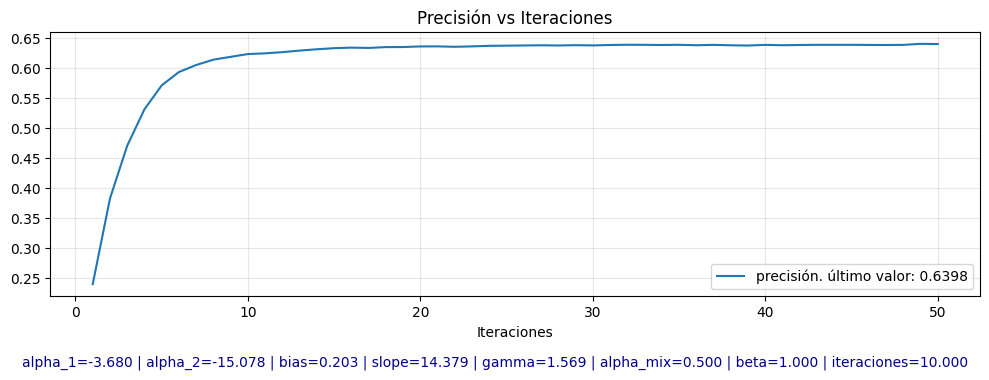

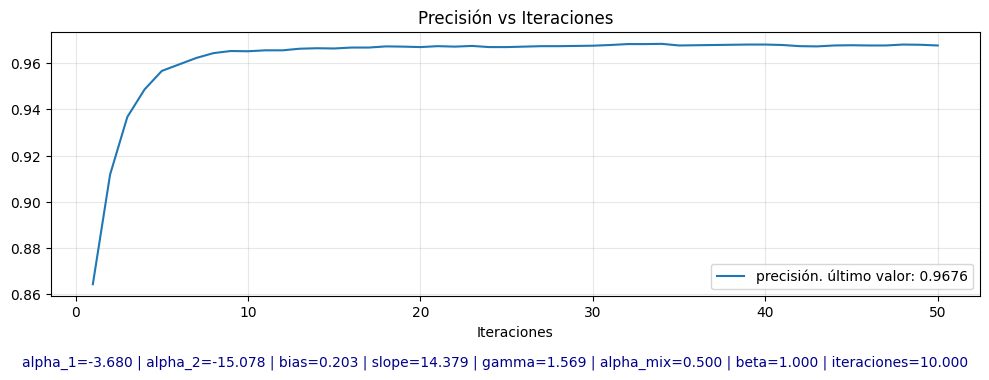

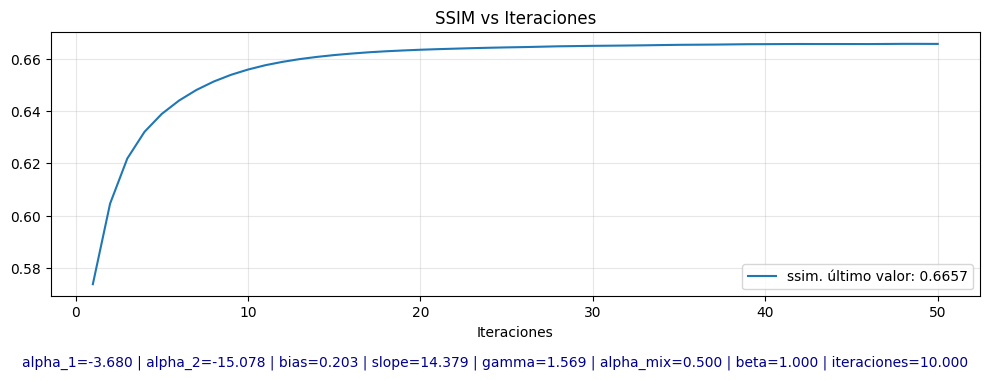

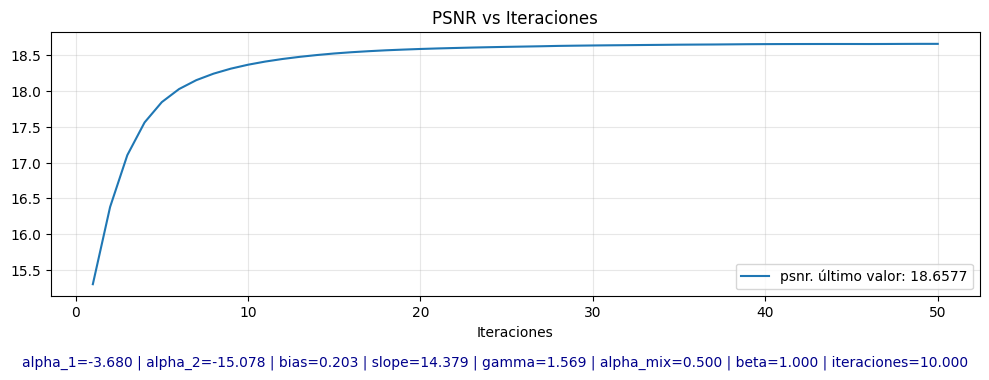


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -3.680
alpha_2     : -15.078
bias        : 0.203
slope       : 14.379
gamma       : 1.569
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.658  std:3.248
mask_bpsnr       : mean: 11.883  std:1.603
ssim             : mean: 0.666  std:0.123
acc_at_least_one : 0.968
acc_both         : 0.640



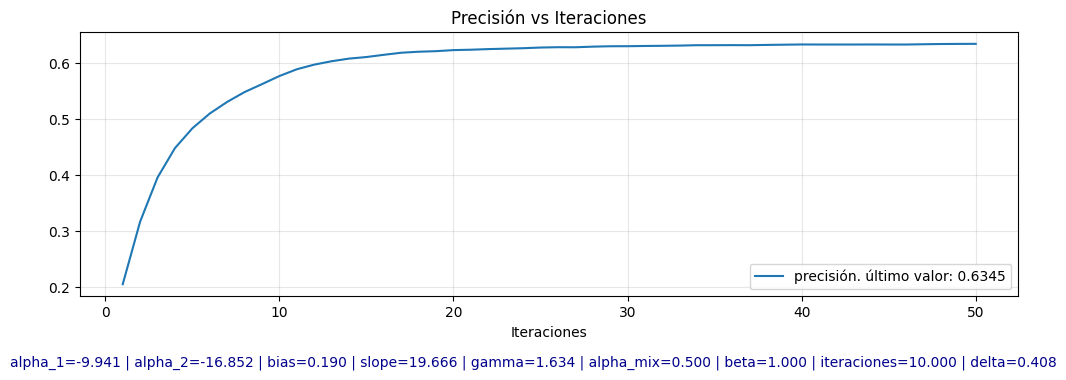

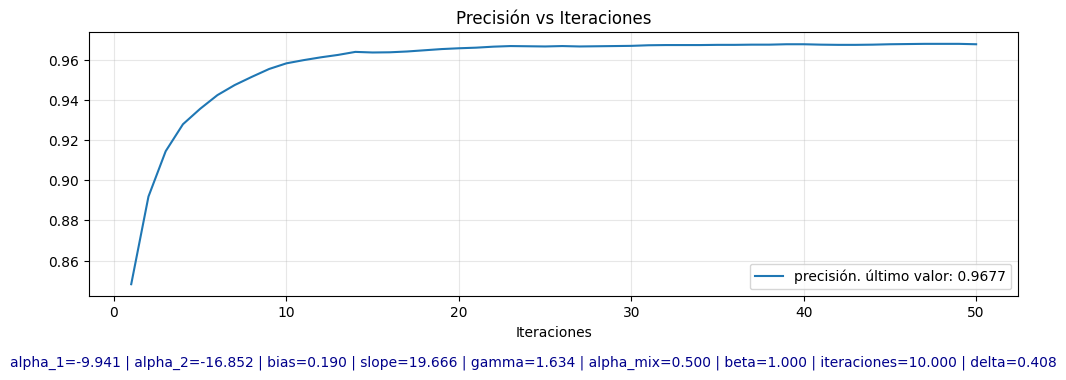

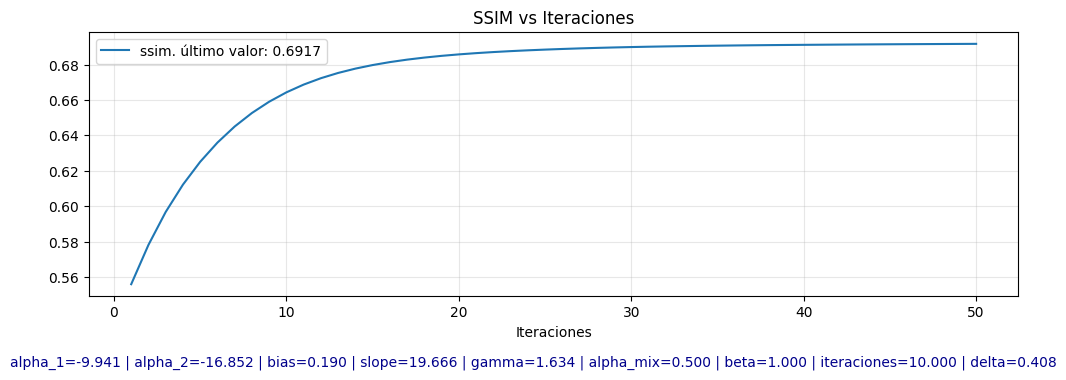

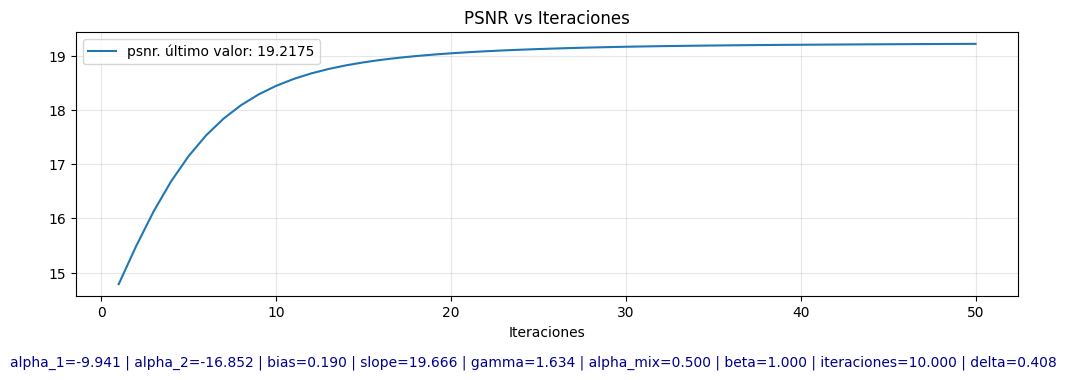


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -9.941
alpha_2     : -16.852
bias        : 0.190
slope       : 19.666
gamma       : 1.634
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.408

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.218  std:3.090
mask_bpsnr       : mean: 10.900  std:1.609
ssim             : mean: 0.692  std:0.105
acc_at_least_one : 0.968
acc_both         : 0.634



In [34]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
from project.CROP.models.crop2 import Crop2
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
from project.CROP.models.crop3_all_corrections import Crop3AllCorrections
from project.CROP.models.crop3_one_hot import Crop3OH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random



DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 256

MNIST_PARAMS={'alpha_1': -1.061219644037281, 
        'alpha_2': -5.93265175032368, 
        'bias': 0.2181251530229756, 
        'slope': 12.884957541103851, 
        'gamma': 0.3294146902334417}

FASHION_PARAMS={'alpha_1': -0.19868397094671308, 
        'alpha_2': -13.487772584723764, 
        'bias': 0.2025587756051315, 
        'slope': 12.603926712541048, 
        'gamma': 1.348637346498534}
#optimizando ssim

FASHION_PARAMS_SSIM={'alpha_1': -3.67958442342705, 
        'alpha_2': -15.077895121548808, 
        'bias': 0.20255676463340044, 
        'slope': 14.379147657210677, 
        'gamma': 1.569064516257034}


MNIST_PARAMS_SSIM={'alpha_1': -1.9353908509805846, 
                   'alpha_2': -5.702371423422697,
                     'bias': 0.25485332997650295,
                       'slope': 18.19613632092573,
                         'gamma': 1.2494901799145723}
#--------------------------------------------------------

FASHION_PARAMS_CROP3={**FASHION_PARAMS, 'delta':  0.477}

cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

N_RUNS = 10

results_crop2 = {
    "acc": [],
    "ssim": [],
    "psnr": []
}

results_crop3 = {
    "acc": [],
    "ssim": [],
    "psnr": []
}

for run in range(N_RUNS):

    print(f"Run {run+1}/{N_RUNS}")

    # --------------------------
    # Randomización grupo 1
    # --------------------------
    idx0 = np.random.permutation(len(x_test))

    X0 = x_test[idx0][:N_PICTURES]
    Y0 = y_test[idx0][:N_PICTURES]

    # --------------------------
    # Randomización grupo 2
    # --------------------------
    idx1 = np.random.permutation(len(x_test_1))

    X1 = x_test_1[idx1][:N_PICTURES]
    Y1 = y_test_1[idx1][:N_PICTURES]

    # ==================================================
    # Crop2
    # ==================================================
    c2 = Crop2(
        cvae=cvae,
        predictor=predictor
    )

    metrics2 = c2.unmix(
        X0,
        X1,
        Y0,
        Y1,
        iterations=ITERATIONS,
        show_image=False,
        labels=labels,
        params=FASHION_PARAMS_SSIM,
        show_all_curves=True
    )

    results_crop2["acc"].append(metrics2["acc_both_plot"])
    results_crop2["ssim"].append(metrics2["ssim_plot"])
    results_crop2["psnr"].append(metrics2["psnr_plot"])

    # ==================================================
    # Crop3 Estimation Correction
    # ==================================================
    c3 = Crop3EstimationCorrection(
        cvae=cvae,
        predictor=predictor
    )

    metrics3 = c3.unmix(
        X0,
        X1,
        Y0,
        Y1,
        iterations=ITERATIONS,
        show_image=False,
        labels=labels,
        params={'alpha_1': -9.941125499313165, 'alpha_2': -16.852458549802762, 'bias': 0.18973246824243017, 'slope': 19.666498382269456, 'gamma': 1.6344295866300675, 'delta': 0.40844153736349087},
        #{'alpha_1': -1.0837446661347714, 'alpha_2': -9.488241278272092, 'bias': 0.1559648766444004, 'slope': 18.869899587059923, 'gamma': 1.3990861311565848, 'delta': 0.24497809943065196},
        show_all_curves=True
    )

    results_crop3["acc"].append(metrics3["acc_both_plot"])
    results_crop3["ssim"].append(metrics3["ssim_plot"])
    results_crop3["psnr"].append(metrics3["psnr_plot"])


# ======================================================
# Conversión a arrays
# ======================================================

for results in [results_crop2, results_crop3]:

    results["acc"] = np.asarray(results["acc"])
    results["ssim"] = np.asarray(results["ssim"])
    results["psnr"] = np.asarray(results["psnr"])

    results["mean_acc"] = results["acc"].mean(axis=0)
    results["std_acc"] = results["acc"].std(axis=0)

    results["mean_ssim"] = results["ssim"].mean(axis=0)
    results["std_ssim"] = results["ssim"].std(axis=0)

    results["mean_psnr"] = results["psnr"].mean(axis=0)
    results["std_psnr"] = results["psnr"].std(axis=0)




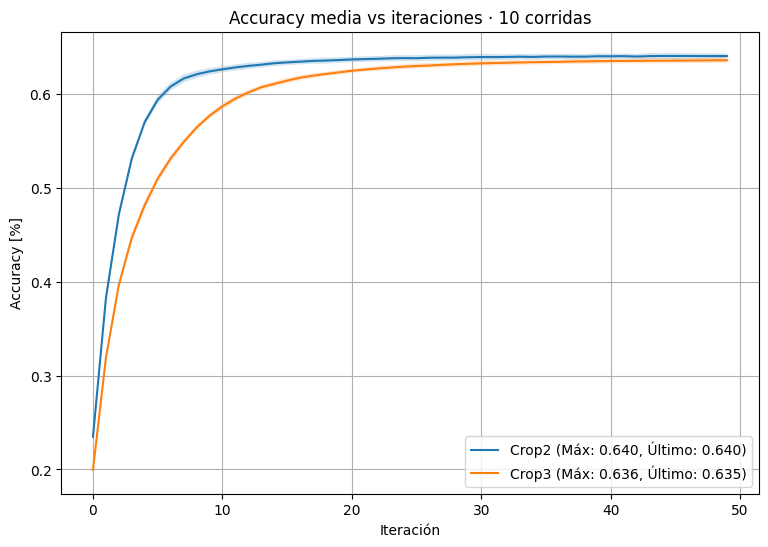

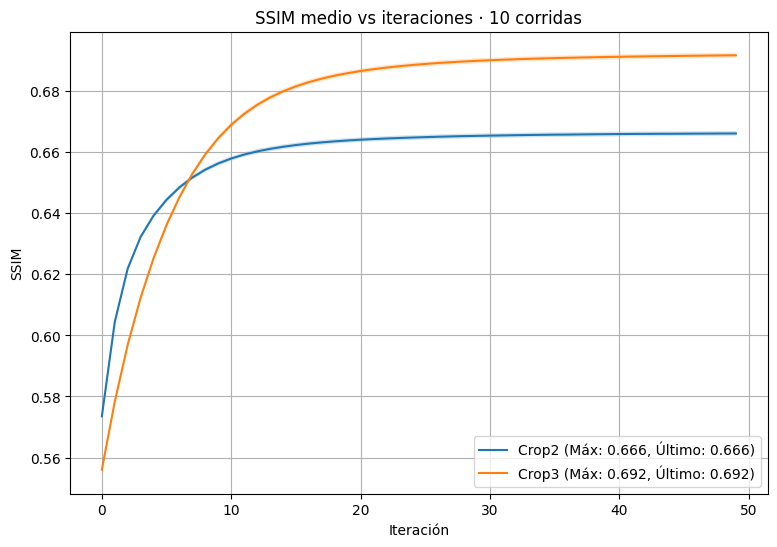

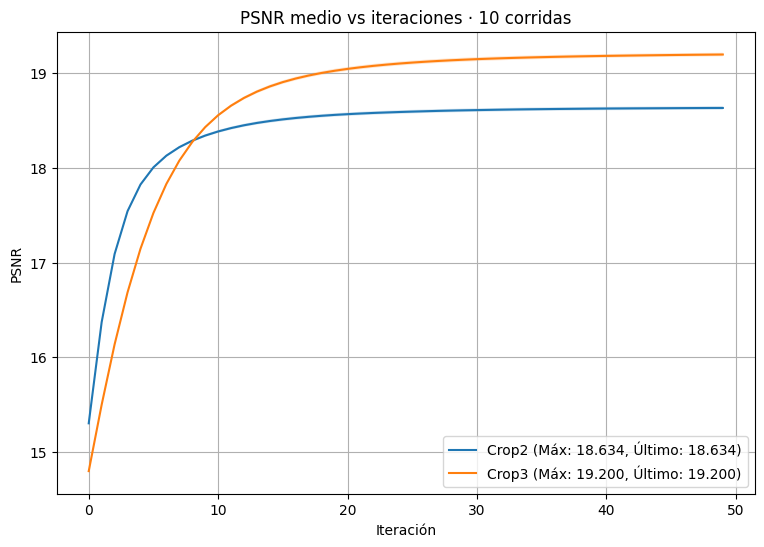

In [35]:
plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    acc = results["mean_acc"]
    std = results["std_acc"]

    x = np.arange(len(acc))

    plt.plot(
        x,
        acc,
        label=f"{name} (Máx: {acc.max():.3f}, Último: {acc[-1]:.3f})"
    )

    plt.fill_between(
        x,
        acc - std,
        acc + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"Accuracy media vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("Accuracy [%]")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    ssim = results["mean_ssim"]
    std = results["std_ssim"]

    x = np.arange(len(ssim))

    plt.plot(
        x,
        ssim,
        label=f"{name} (Máx: {ssim.max():.3f}, Último: {ssim[-1]:.3f})"
    )

    plt.fill_between(
        x,
        ssim - std,
        ssim + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"SSIM medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("SSIM")
plt.legend()
plt.show()



plt.figure(figsize=(9, 6))

for name, results in {
    "Crop2": results_crop2,
    "Crop3": results_crop3
}.items():

    psnr = results["mean_psnr"]
    std = results["std_psnr"]

    x = np.arange(len(psnr))

    plt.plot(
        x,
        psnr,
        label=f"{name} (Máx: {psnr.max():.3f}, Último: {psnr[-1]:.3f})"
    )

    plt.fill_between(
        x,
        psnr - std,
        psnr + std,
        alpha=0.2
    )

plt.grid()
plt.title(f"PSNR medio vs iteraciones · {N_RUNS} corridas")
plt.xlabel("Iteración")
plt.ylabel("PSNR")
plt.legend()
plt.show()